In [ ]:
!pip -q install torch pytorch-lightning torchmetrics pytorch-forecasting


In [ ]:
!pip -q install statsmodels


In [ ]:

!pip -q install statsmodels


In [ ]:
import numpy as np
import pandas as pd
import warnings, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from statsmodels.tsa.statespace.sarimax import SARIMAX

TRAIN_PATH = "./sample_data/trainlimpio.csv"
TEST_PATH  = "./sample_data/testlimpio.csv"
DATE_COL   = "date_id"

instruments = {
    'JPX_Gold_Standard_Futures': ['Close', 'High', 'Low', 'Open'],
    'JPX_Gold_Mini_Futures': ['settlement_price', 'High', 'Low', 'Close', 'Open'],
}

MULTI_TARGET = False
LOOKBACK     = 64
BATCH_SIZE   = 64
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
SEED         = 42
np.random.seed(SEED); torch.manual_seed(SEED)

def plot_loss_curve(loss_hist, title):
    plt.figure(figsize=(8,4))
    plt.plot(loss_hist, lw=2)
    plt.xlabel("Época"); plt.ylabel("MSE (train)"); plt.title(title)
    plt.tight_layout(); plt.show(); plt.close()

def plot_series(dates, y_true, y_pred, title):
    plt.figure(figsize=(12,4))
    if dates is not None:
        plt.plot(dates, y_true, label="Real", lw=1.5)
        plt.plot(dates, y_pred, label="Predicho", lw=1.5)
        plt.xticks(rotation=45)
    else:
        plt.plot(y_true, label="Real", lw=1.5)
        plt.plot(y_pred, label="Predicho", lw=1.5)
    plt.legend(); plt.title(title); plt.tight_layout(); plt.show(); plt.close()

def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.7)
    lims = [min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))]
    plt.plot(lims, lims, 'k--', lw=1); plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Real"); plt.ylabel("Predicho"); plt.title(title)
    plt.tight_layout(); plt.show(); plt.close()

def plot_residuals(dates, residuals, title_prefix):
    plt.figure(figsize=(12,3))
    if dates is not None:
        plt.plot(dates, residuals, lw=1); plt.xticks(rotation=45)
    else:
        plt.plot(residuals, lw=1)
    plt.axhline(0, color='k', lw=1)
    plt.title(f"{title_prefix} - Residuales (línea)")
    plt.tight_layout(); plt.show(); plt.close()

    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=30, alpha=0.85)
    plt.title(f"{title_prefix} - Residuales (histograma)")
    plt.tight_layout(); plt.show(); plt.close()

CONST_THR = 1e-8

def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback, :])
        ys.append(y[i+lookback, :])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

def drop_all_nan(train, test, date_col):
    all_nan_cols = [c for c in train.columns if c != date_col and train[c].isna().all()]
    all_nan_test = [c for c in test.columns if c != date_col and test[c].isna().all()]
    all_nan_cols = sorted(set(all_nan_cols + all_nan_test))
    if all_nan_cols:
        train = train.drop(columns=all_nan_cols, errors="ignore")
        test  = test.drop(columns=all_nan_cols, errors="ignore")
    return train, test

def drop_near_constant(train, test, date_col, thr=CONST_THR):
    stds = train.drop(columns=[date_col]).std(axis=0)
    near_const = stds[stds <= thr].index.tolist()
    keep = [c for c in train.columns if c not in near_const]
    return train[keep], test[keep]

def build_target_columns(instruments_dict):
    cols, seen = [], set()
    for base, fields in instruments_dict.items():
        for f in fields:
            col = f"{base}_{f}"
            if col not in seen:
                seen.add(col); cols.append(col)
    return cols

train_df = pd.read_csv(TRAIN_PATH).sort_values(DATE_COL).reset_index(drop=True)
test_df  = pd.read_csv(TEST_PATH).sort_values(DATE_COL).reset_index(drop=True)

extra_in_test = [c for c in test_df.columns if c not in train_df.columns]
if extra_in_test:
    print("Eliminando columnas extra en test:", extra_in_test)
    test_df = test_df.drop(columns=extra_in_test, errors="ignore")

common_cols = [c for c in train_df.columns if c in test_df.columns]
train_df, test_df = train_df[common_cols], test_df[common_cols]

train_df = train_df.fillna(method="ffill").fillna(method="bfill")
test_df  = test_df.fillna(method="ffill").fillna(method="bfill")

for df in (train_df, test_df):
    for c in df.columns:
        if df[c].dtype == "bool":
            df[c] = df[c].astype(int)

train_df, test_df = drop_all_nan(train_df, test_df, DATE_COL)
train_df, test_df = drop_near_constant(train_df, test_df, DATE_COL, CONST_THR)

ALL_TARGETS = [t for t in build_target_columns(instruments) if t in train_df.columns and t in test_df.columns]
assert len(ALL_TARGETS) > 0, "No se encontraron columnas objetivo en los CSV según 'instruments'."
print(f"Targets detectados ({len(ALL_TARGETS)}):\n{ALL_TARGETS}")

num_cols = [c for c in train_df.columns if c != DATE_COL and np.issubdtype(train_df[c].dtype, np.number)]
feature_cols = [c for c in num_cols if (c not in ALL_TARGETS)] if MULTI_TARGET else num_cols

x_scaler = MinMaxScaler()
X_train_all = x_scaler.fit_transform(train_df[feature_cols].values)
X_test_all  = x_scaler.transform(test_df[feature_cols].values)

test_dates = test_df[DATE_COL].iloc[LOOKBACK:].to_numpy() if DATE_COL in test_df.columns else None


Eliminando columnas extra en test: ['is_scored']
Targets detectados (9):
['JPX_Gold_Standard_Futures_Close', 'JPX_Gold_Standard_Futures_High', 'JPX_Gold_Standard_Futures_Low', 'JPX_Gold_Standard_Futures_Open', 'JPX_Gold_Mini_Futures_settlement_price', 'JPX_Gold_Mini_Futures_High', 'JPX_Gold_Mini_Futures_Low', 'JPX_Gold_Mini_Futures_Close', 'JPX_Gold_Mini_Futures_Open']


In [ ]:

import os, re, json, shutil, io
from datetime import datetime
from contextlib import redirect_stdout, redirect_stderr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUN_TAG    = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"./outputs_{RUN_TAG}"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figs")
TXT_DIR    = os.path.join(OUTPUT_DIR, "txt")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TXT_DIR, exist_ok=True)

def _slug(s):
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", str(s))


_stdout_cm = None
_stderr_cm = None
_log_stream = None

def start_log_capture():
    global _stdout_cm, _stderr_cm, _log_stream
    _log_stream = io.StringIO()
    _stdout_cm = redirect_stdout(_log_stream)
    _stderr_cm = redirect_stderr(_log_stream)
    _stdout_cm.__enter__(); _stderr_cm.__enter__()
    print(f"[LOG] Captura iniciada. Carpeta: {OUTPUT_DIR}")

def stop_and_save_log(filename="run_log.txt"):
    global _stdout_cm, _stderr_cm, _log_stream
    if _stderr_cm: _stderr_cm.__exit__(None, None, None)
    if _stdout_cm: _stdout_cm.__exit__(None, None, None)
    path = os.path.join(TXT_DIR, filename)
    with open(path, "w", encoding="utf-8") as f:
        f.write(_log_stream.getvalue() if _log_stream else "")
    print("Log guardado en:", path)


def append_result_txt(line, fname="metrics.txt"):
    path = os.path.join(TXT_DIR, fname)
    with open(path, "a", encoding="utf-8") as f:
        f.write(str(line).rstrip() + "\n")


def save_current_fig(stem, dpi=150):
    path = os.path.join(FIG_DIR, f"{_slug(stem)}.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Figura guardada:", path)

def plot_series_save(dates, y_true, y_pred, title, fname_stem):
    plt.figure(figsize=(12,4))
    if dates is not None:
        plt.plot(dates, y_true, label="Real", lw=1.5)
        plt.plot(dates, y_pred, label="Predicho", lw=1.5)
        plt.xticks(rotation=45)
    else:
        plt.plot(y_true, label="Real", lw=1.5)
        plt.plot(y_pred, label="Predicho", lw=1.5)
    plt.title(title); plt.legend(); plt.tight_layout()
    save_current_fig(fname_stem); plt.show(); plt.close()

def plot_scatter_save(y_true, y_pred, title, fname_stem):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.7)
    lims = [min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))]
    plt.plot(lims, lims, 'k--', lw=1)
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Real"); plt.ylabel("Predicho"); plt.title(title)
    plt.tight_layout()
    save_current_fig(fname_stem); plt.show(); plt.close()

def plot_residuals_save(dates, residuals, title_prefix, fname_stem):
    plt.figure(figsize=(12,3))
    if dates is not None:
        plt.plot(dates, residuals, lw=1); plt.xticks(rotation=45)
    else:
        plt.plot(residuals, lw=1)
    plt.axhline(0, color='k', lw=1)
    plt.title(f"{title_prefix} - Residuales (línea)")
    plt.tight_layout()
    save_current_fig(fname_stem + "_line"); plt.show(); plt.close()

    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=30, alpha=0.85)
    plt.title(f"{title_prefix} - Residuales (histograma)")
    plt.tight_layout()
    save_current_fig(fname_stem + "_hist"); plt.show(); plt.close()


def make_zip():
    zip_path = shutil.make_archive(OUTPUT_DIR, "zip", OUTPUT_DIR)
    print("ZIP listo:", zip_path)
    try:
        from google.colab import files
        files.download(zip_path)
    except Exception:
        pass



=== ARIMA (walk-forward) ===

--- ARIMA para: JPX_Gold_Standard_Futures_Close ---
Orden (p,d,q) elegido: (2, 1, 2)
[JPX_Gold_Standard_Futures_Close] MAE=132.1751  MSE=68646.9650  RMSE=262.0057


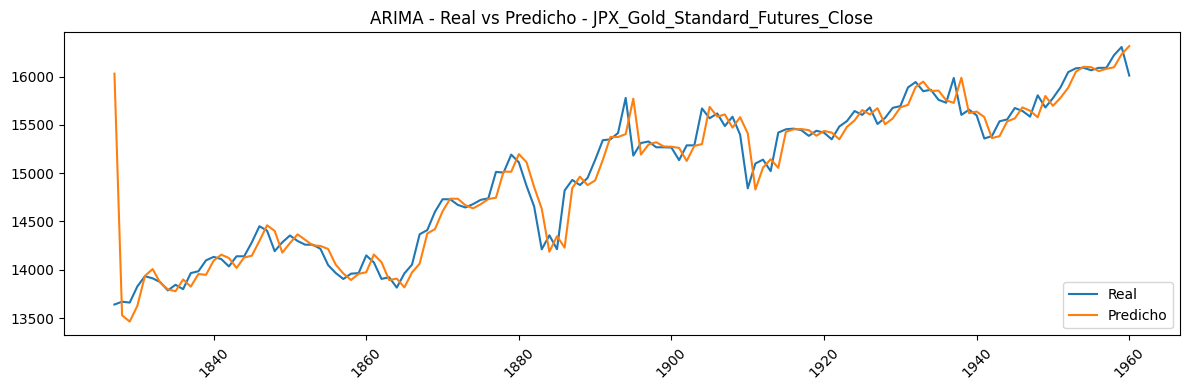

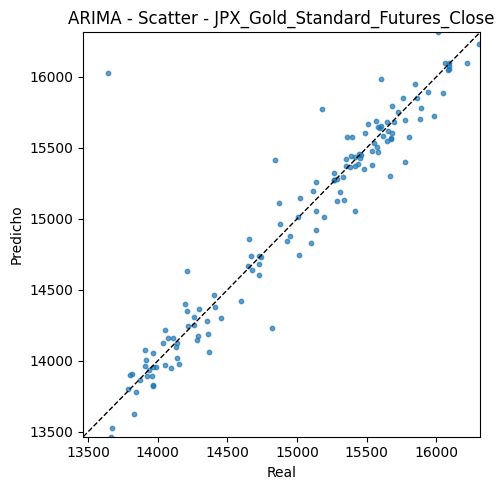

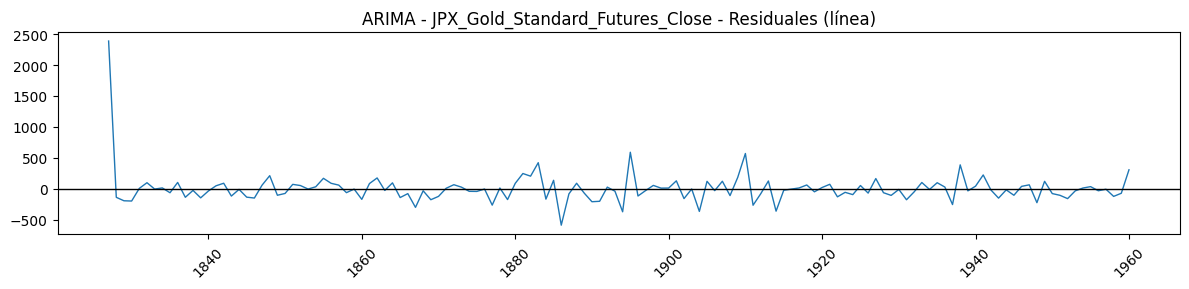

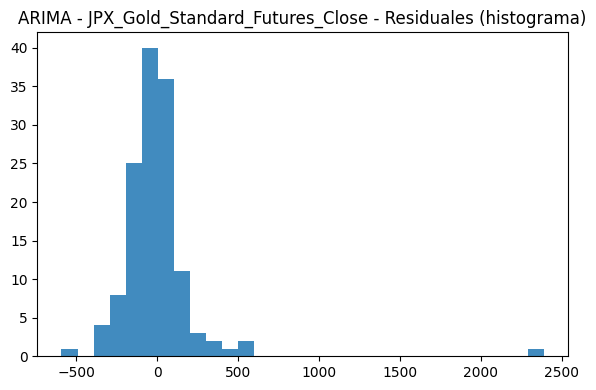


--- ARIMA para: JPX_Gold_Standard_Futures_High ---
Orden (p,d,q) elegido: (1, 0, 2)
[JPX_Gold_Standard_Futures_High] MAE=113.6431  MSE=69136.3784  RMSE=262.9380


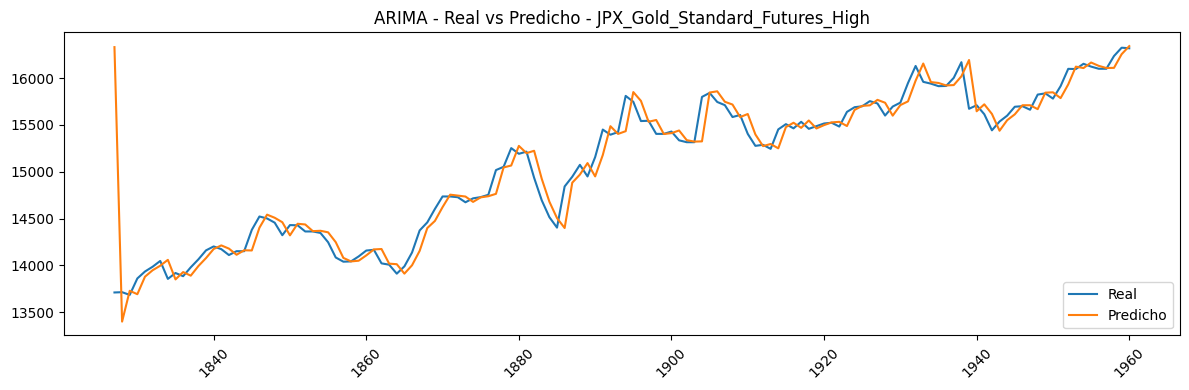

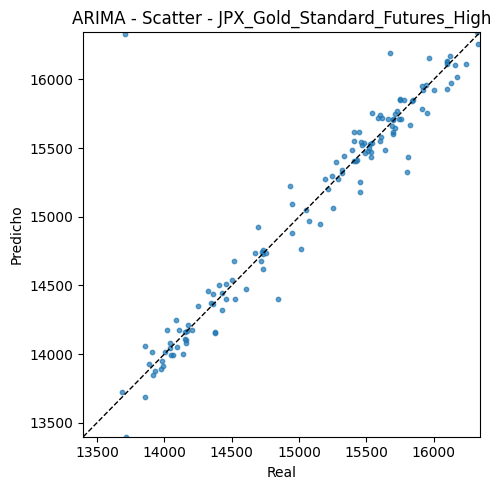

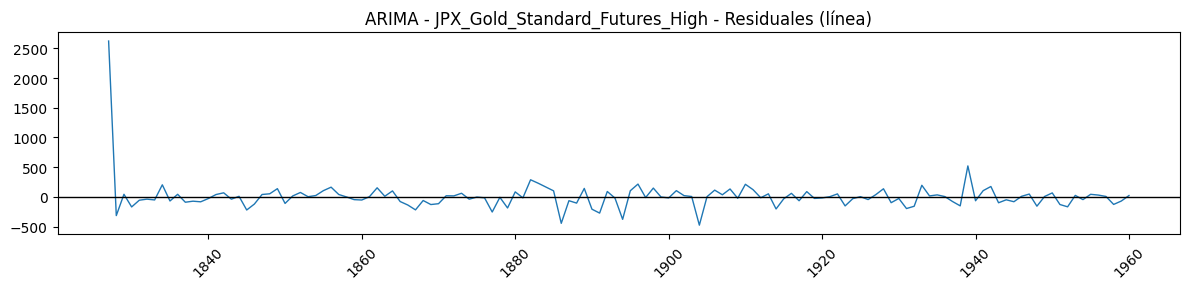

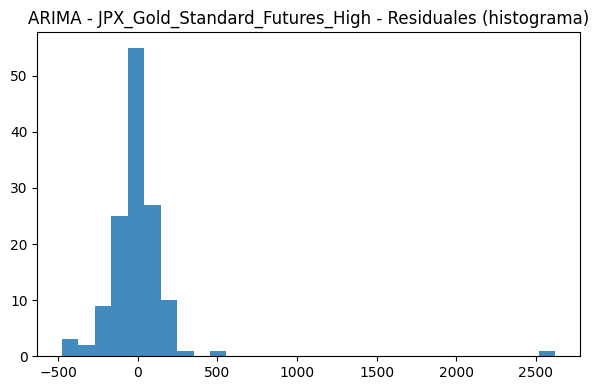


--- ARIMA para: JPX_Gold_Standard_Futures_Low ---
Orden (p,d,q) elegido: (2, 0, 2)
[JPX_Gold_Standard_Futures_Low] MAE=125.8671  MSE=64287.6201  RMSE=253.5500


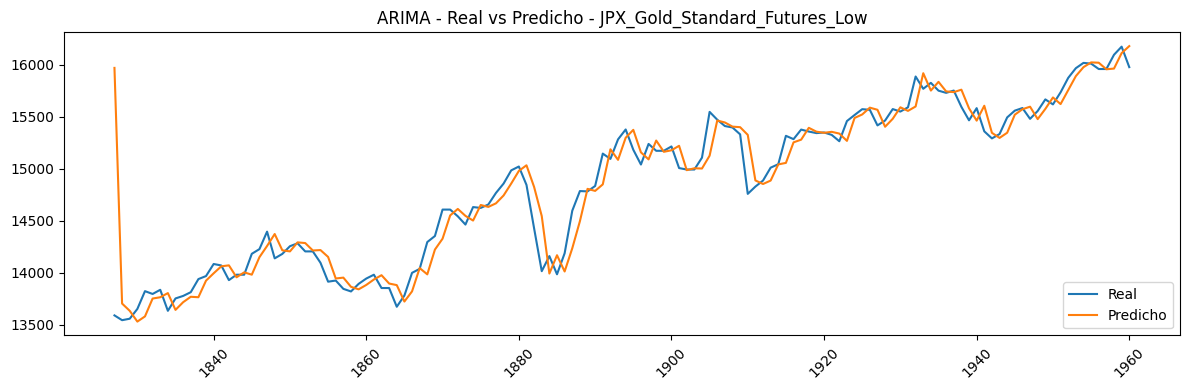

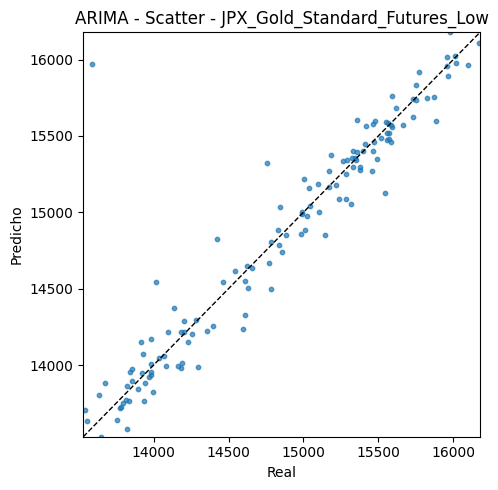

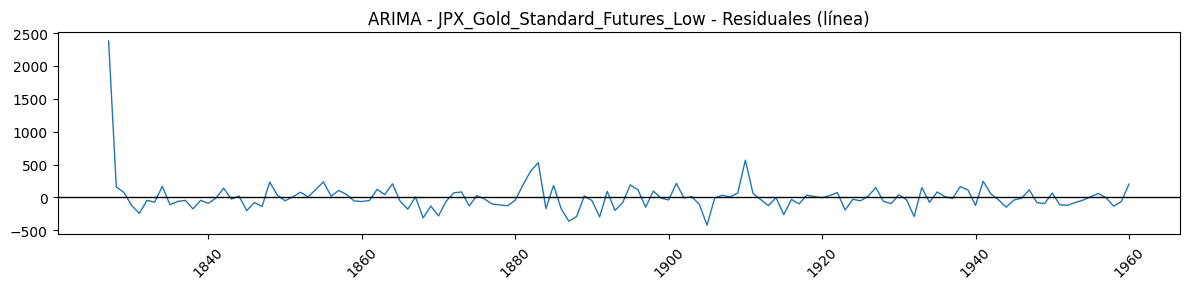

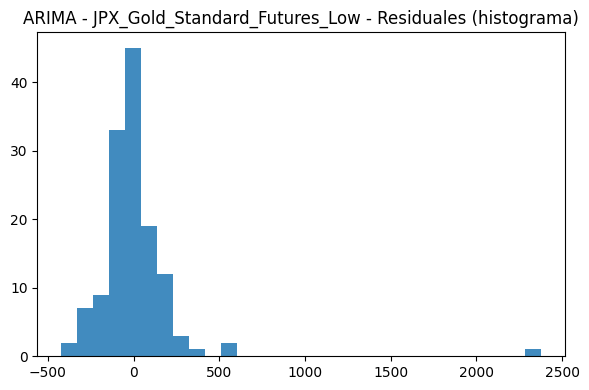


--- ARIMA para: JPX_Gold_Standard_Futures_Open ---
Orden (p,d,q) elegido: (2, 1, 2)
[JPX_Gold_Standard_Futures_Open] MAE=126.5543  MSE=76049.2821  RMSE=275.7703


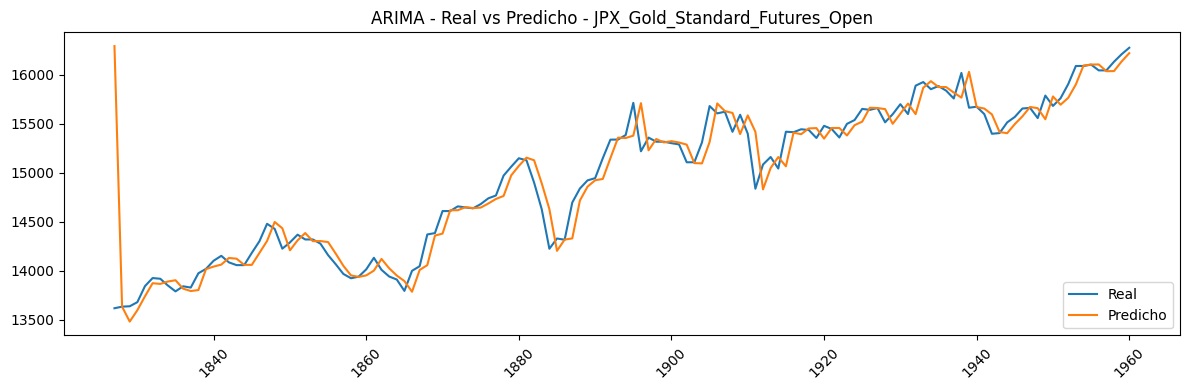

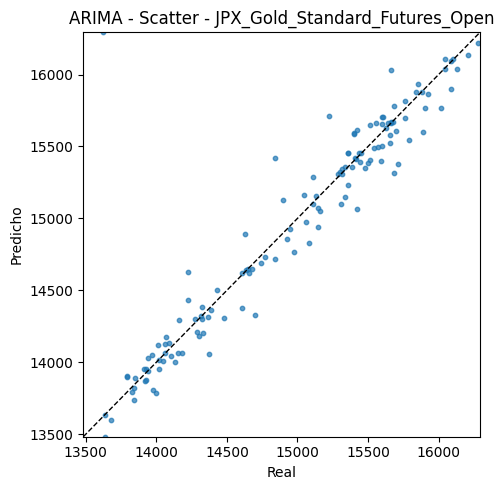

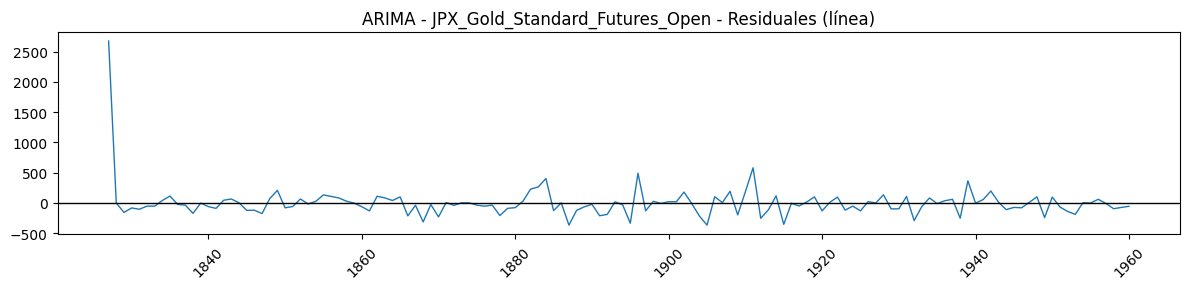

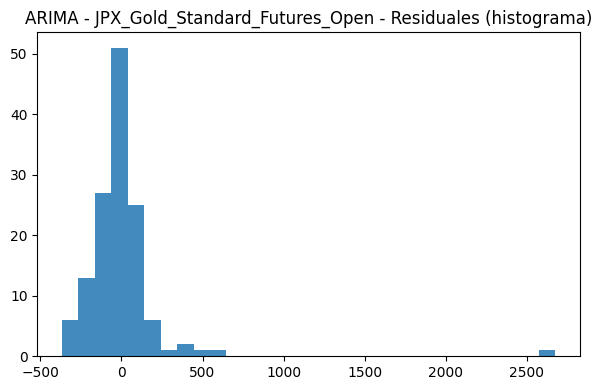


--- ARIMA para: JPX_Gold_Mini_Futures_settlement_price ---
Orden (p,d,q) elegido: (2, 1, 2)
[JPX_Gold_Mini_Futures_settlement_price] MAE=131.9075  MSE=68561.3082  RMSE=261.8421


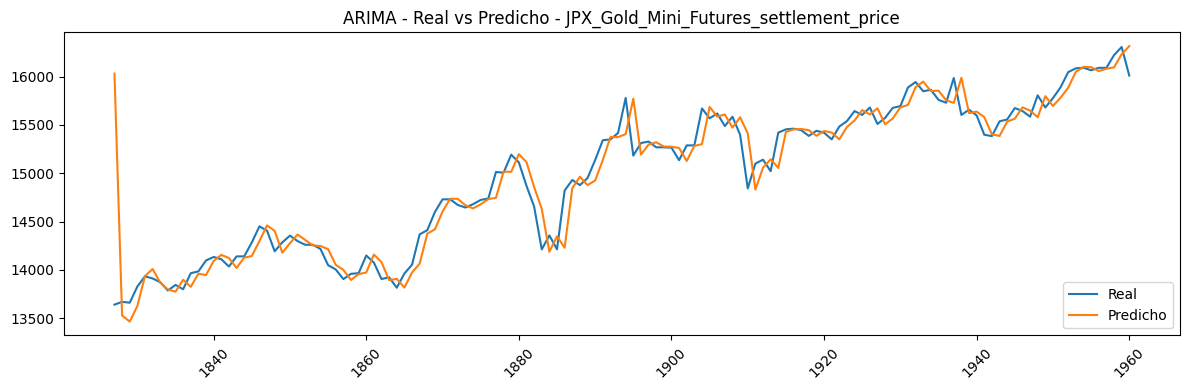

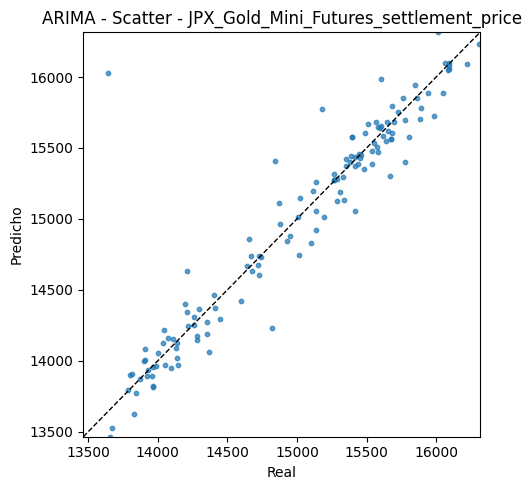

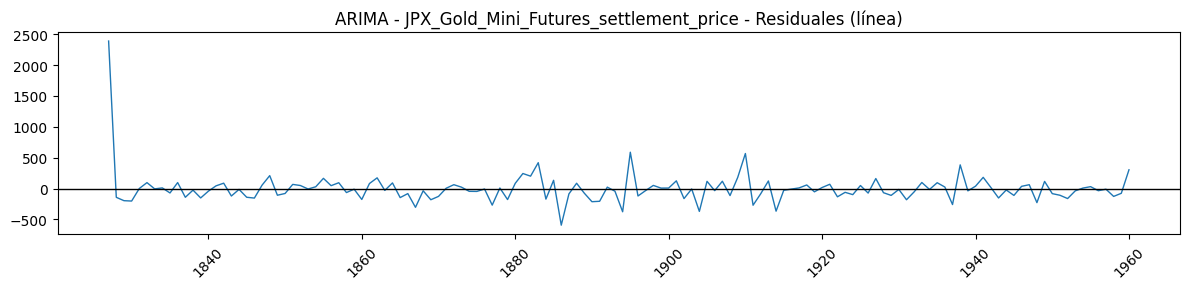

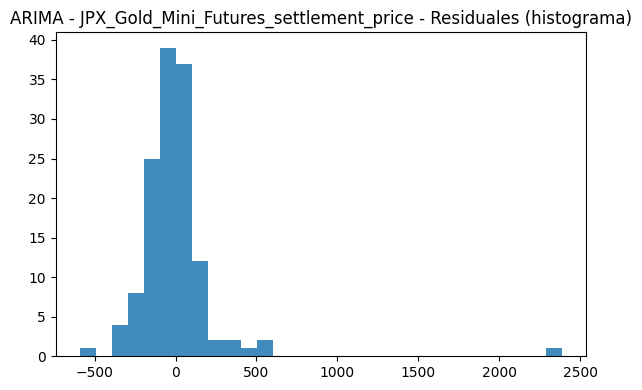


--- ARIMA para: JPX_Gold_Mini_Futures_High ---
Orden (p,d,q) elegido: (1, 0, 2)
[JPX_Gold_Mini_Futures_High] MAE=113.0129  MSE=68947.8190  RMSE=262.5792


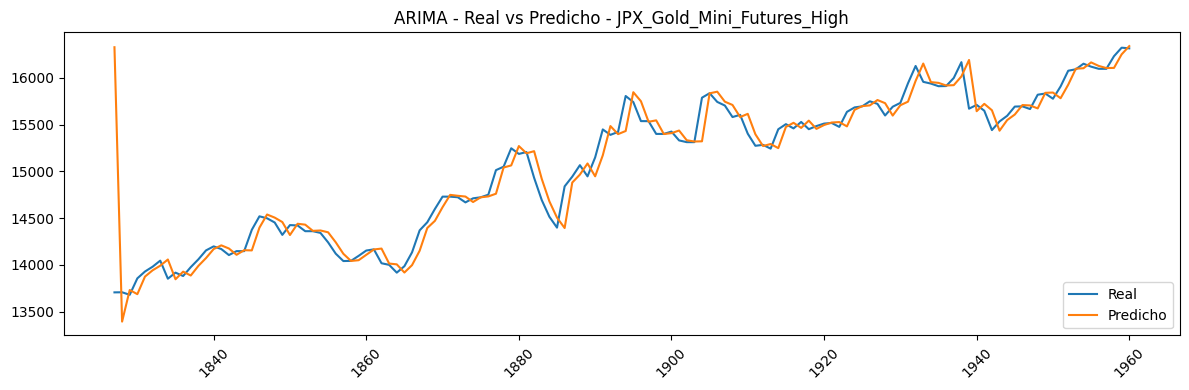

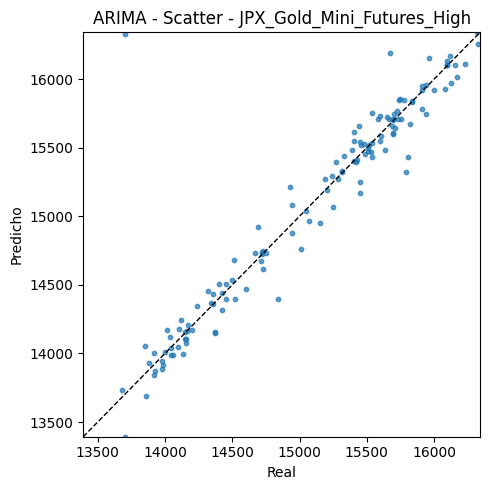

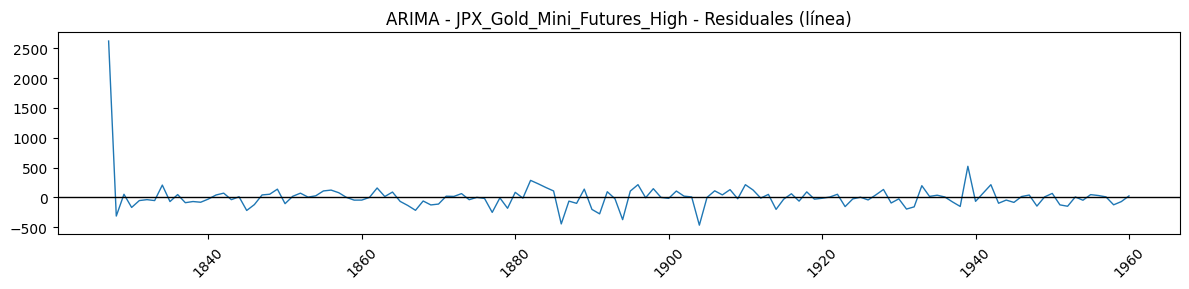

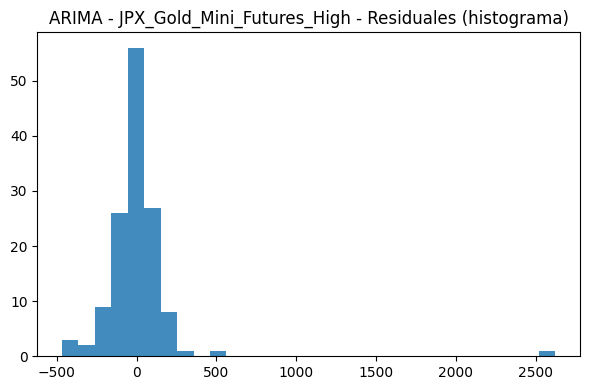


--- ARIMA para: JPX_Gold_Mini_Futures_Low ---
Orden (p,d,q) elegido: (1, 0, 2)
[JPX_Gold_Mini_Futures_Low] MAE=125.1253  MSE=63356.7895  RMSE=251.7077


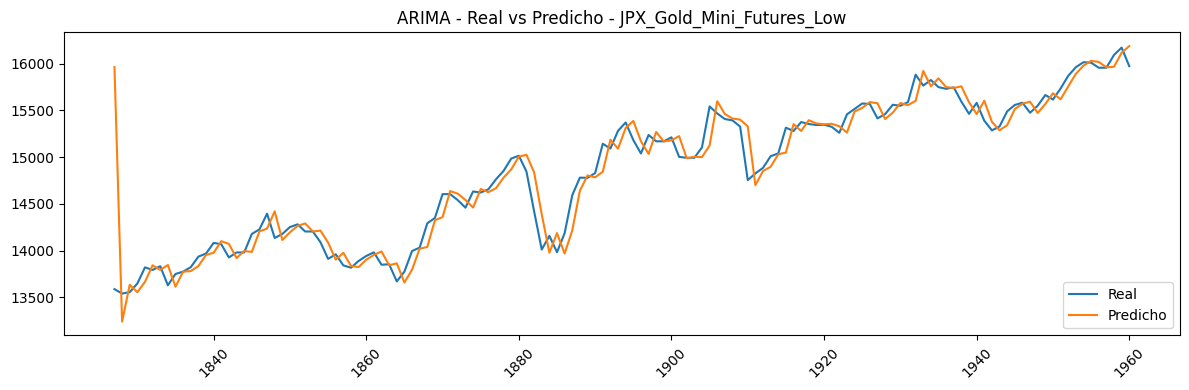

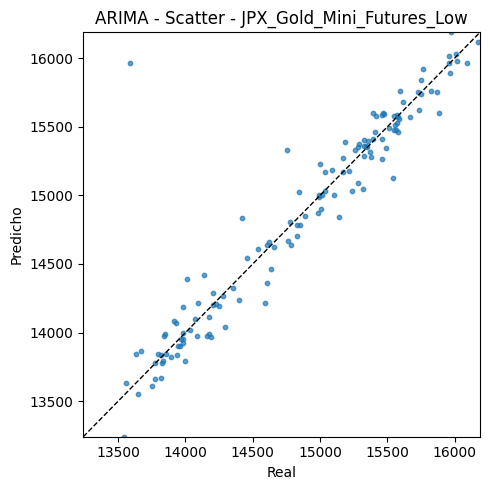

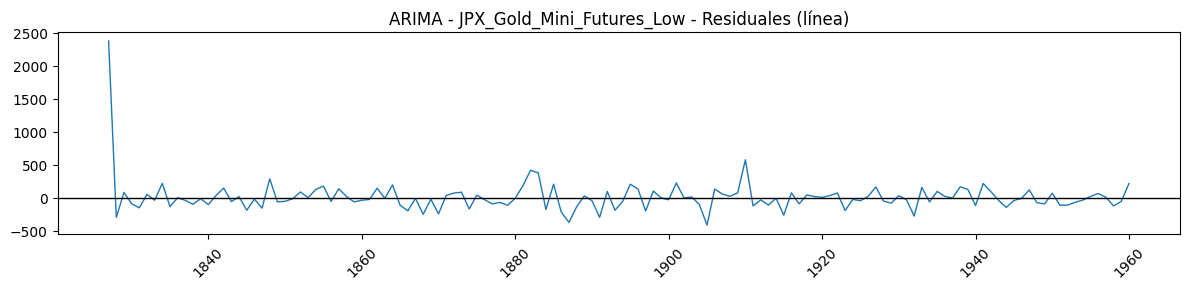

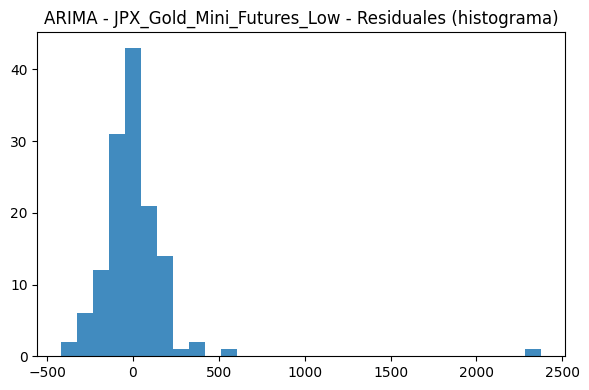


--- ARIMA para: JPX_Gold_Mini_Futures_Close ---
Orden (p,d,q) elegido: (2, 1, 2)
[JPX_Gold_Mini_Futures_Close] MAE=130.5718  MSE=67576.4532  RMSE=259.9547


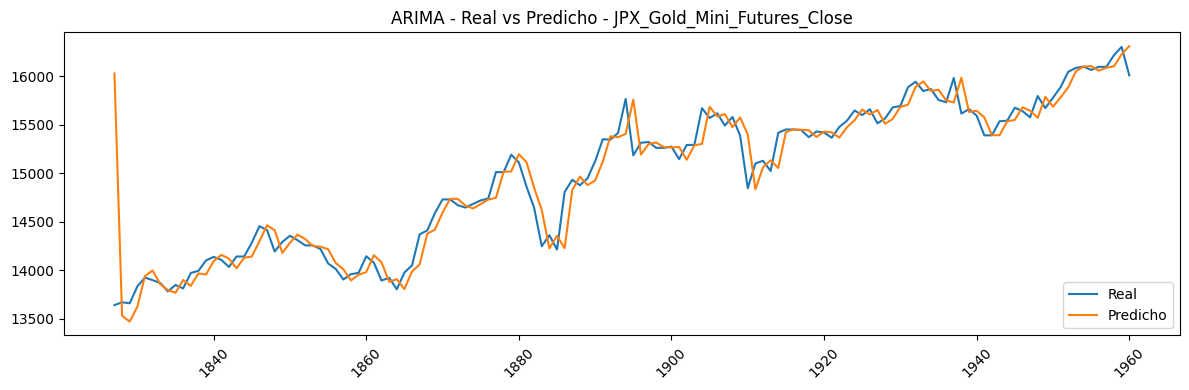

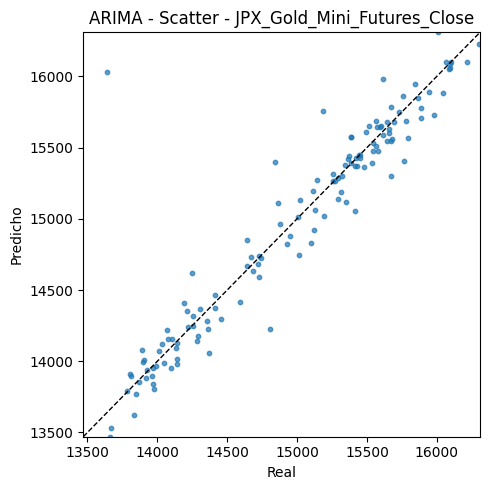

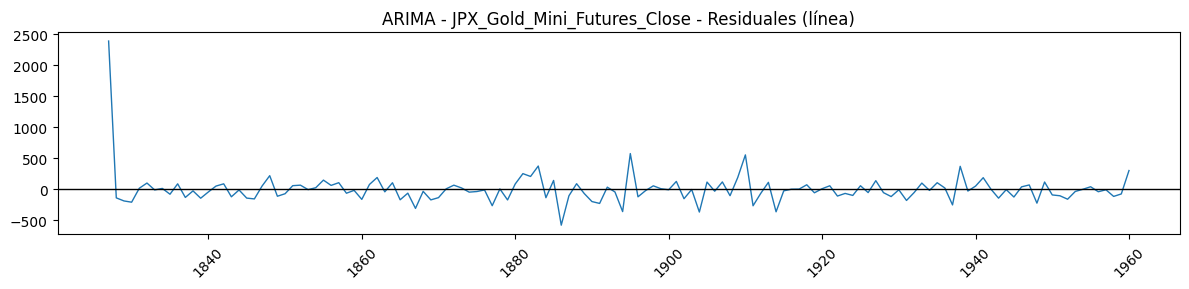

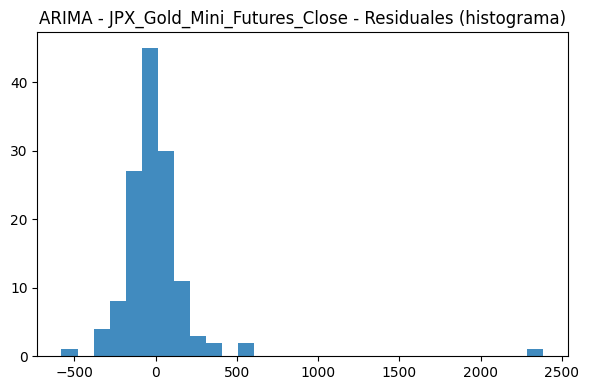


--- ARIMA para: JPX_Gold_Mini_Futures_Open ---
Orden (p,d,q) elegido: (2, 1, 2)
[JPX_Gold_Mini_Futures_Open] MAE=126.4541  MSE=75190.6057  RMSE=274.2091


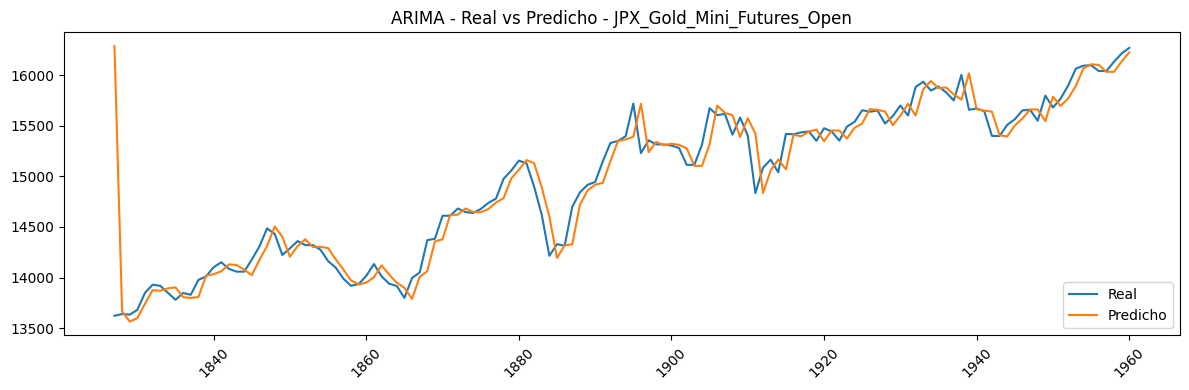

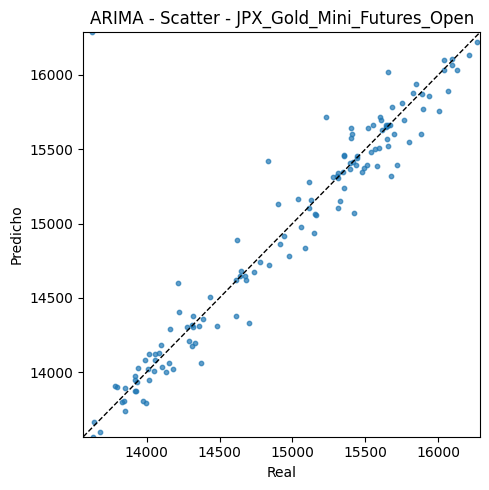

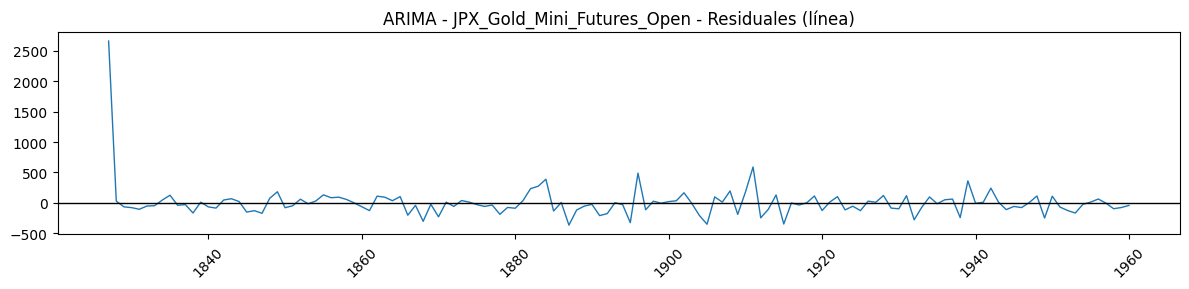

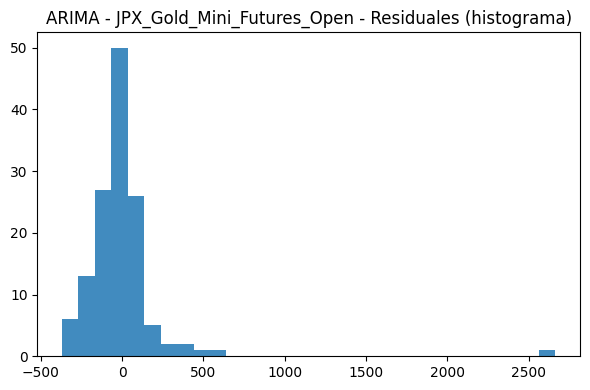

In [ ]:

import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def _select_arima_order(y_train, p_list=(0,1,2), d_list=(0,1), q_list=(0,1,2)):
    best = (0,0,0); best_aic = np.inf
    for p in p_list:
        for d in d_list:
            for q in q_list:
                try:
                    r = SARIMAX(y_train, order=(p,d,q),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if r.aic < best_aic:
                        best_aic = r.aic; best = (p,d,q)
                except Exception:
                    pass
    return best

def _align_dates(dates_arr, y_vec):
    if dates_arr is None:
        return None
    if len(dates_arr) == len(y_vec):
        return dates_arr
    if len(dates_arr) > len(y_vec):
        return dates_arr[-len(y_vec):]
    return None

print("\n=== ARIMA (walk-forward) ===")
arima_results = []

for tcol in ALL_TARGETS:
    print(f"\n--- ARIMA para: {tcol} ---")

    y_tr = train_df[[tcol]].values.astype(float).reshape(-1)
    y_te = test_df[[tcol]].values.astype(float).reshape(-1)

    dates_arima = None
    if DATE_COL in test_df.columns:
        dates_arima = test_df[DATE_COL].to_numpy()

    p, d, q = _select_arima_order(y_tr)
    print("Orden (p,d,q) elegido:", (p, d, q))

    history = list(y_tr)
    preds = []
    for t in range(len(y_te)):
        try:
            r = SARIMAX(history, order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
            yhat = r.forecast(steps=1)[0]
        except Exception:
            yhat = history[-1]
        preds.append(yhat)
        history.append(y_te[t])

    y_true = y_te.reshape(-1, 1)
    y_pred = np.array(preds, dtype=float).reshape(-1, 1)

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"[{tcol}] MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")
    arima_results.append(("ARIMA", tcol, float(mae), float(mse), float(rmse)))

    y_true_1d = y_true.ravel()
    y_pred_1d = y_pred.ravel()
    dates_use = _align_dates(dates_arima, y_true_1d)

    plot_series(dates_use, y_true_1d, y_pred_1d, f"ARIMA - Real vs Predicho - {tcol}")
    plot_scatter(y_true_1d, y_pred_1d, f"ARIMA - Scatter - {tcol}")
    plot_residuals(dates_use, (y_pred_1d - y_true_1d), f"ARIMA - {tcol}")





=== Regresión Lineal (ventanas) ===

--- Linear Regression para: JPX_Gold_Standard_Futures_Close ---
[JPX_Gold_Standard_Futures_Close] MAE=38.5581  MSE=2760.9675  RMSE=52.5449


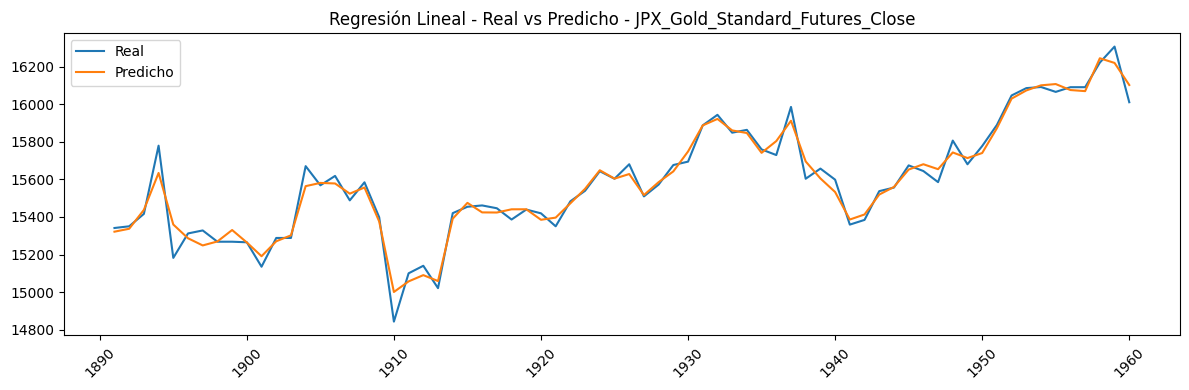

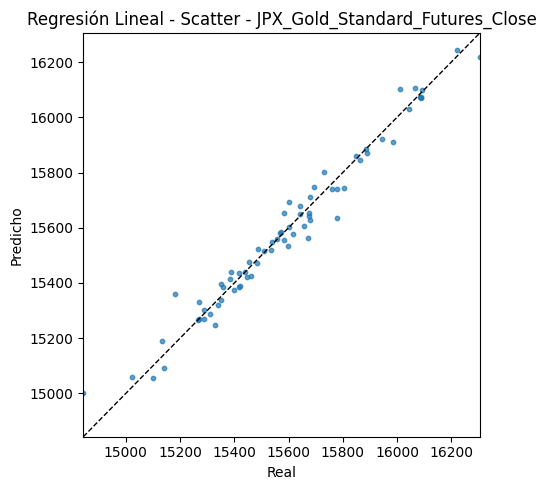

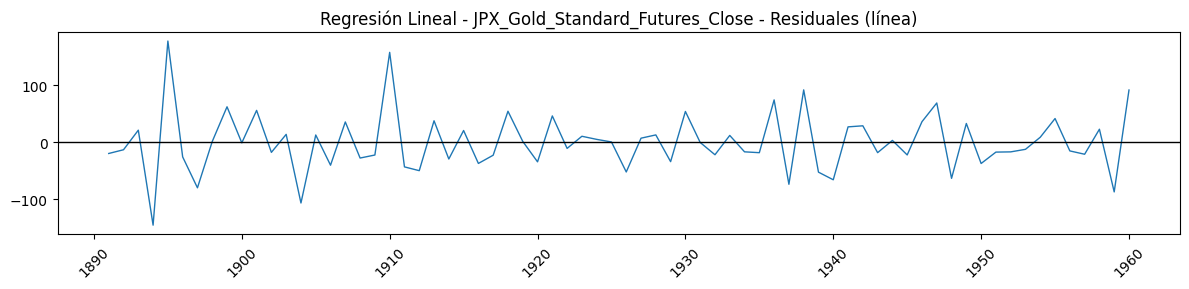

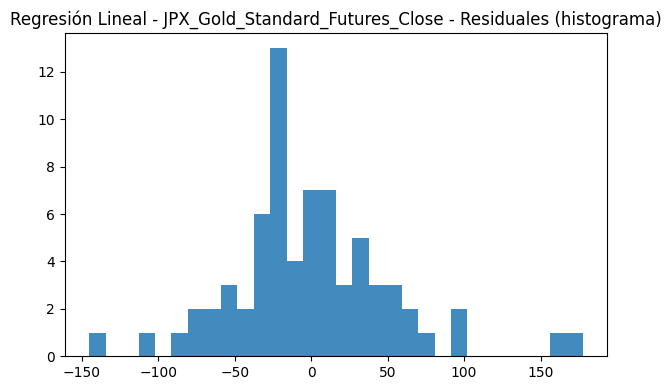


--- Linear Regression para: JPX_Gold_Standard_Futures_High ---
[JPX_Gold_Standard_Futures_High] MAE=29.5067  MSE=1583.4473  RMSE=39.7926


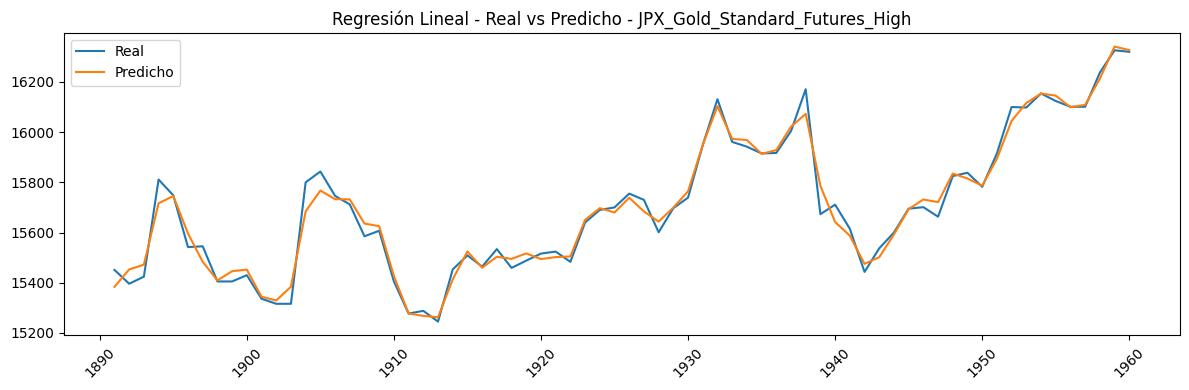

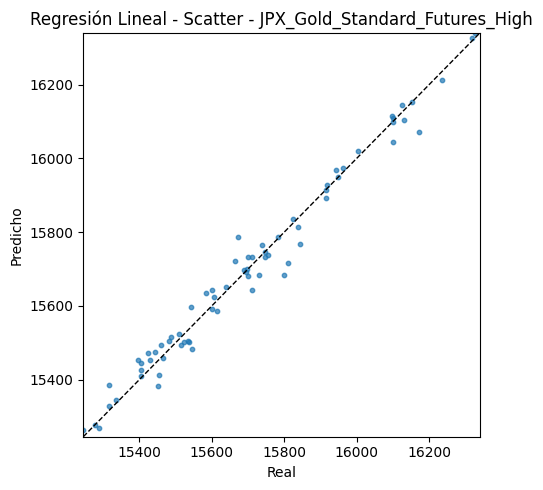

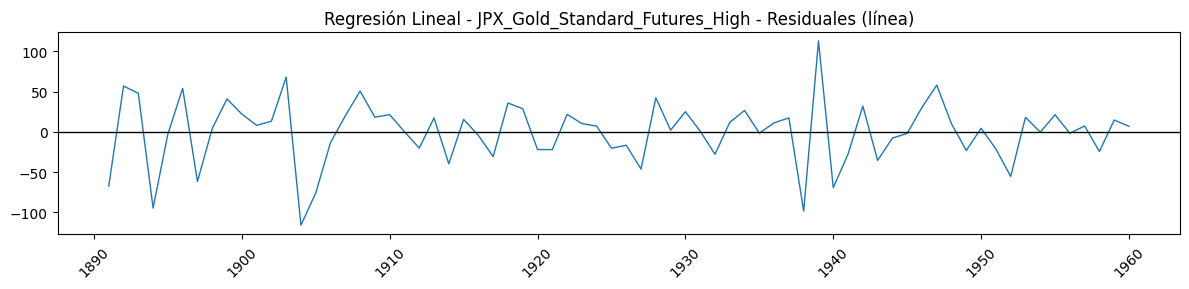

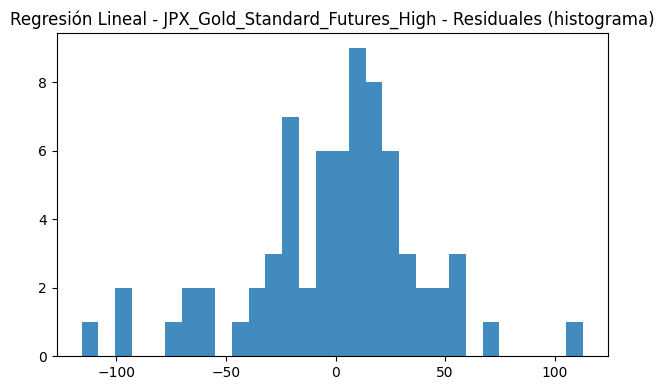


--- Linear Regression para: JPX_Gold_Standard_Futures_Low ---
[JPX_Gold_Standard_Futures_Low] MAE=27.1758  MSE=1313.7611  RMSE=36.2458


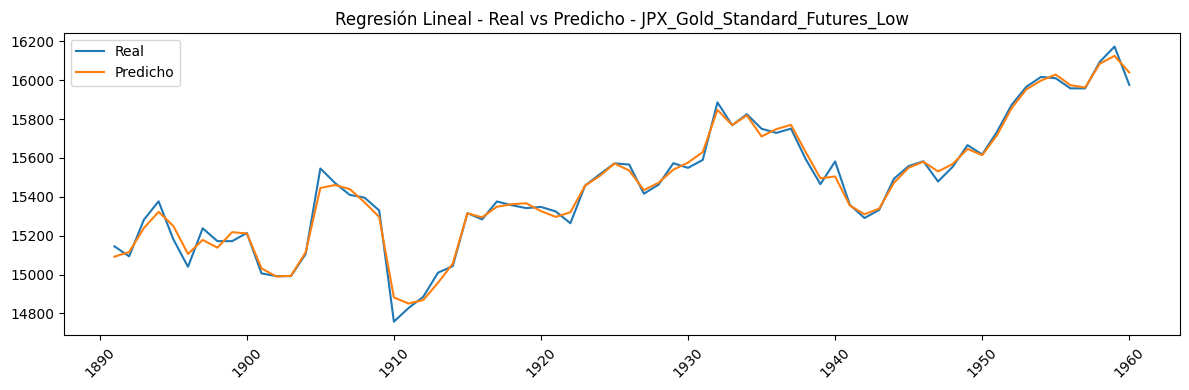

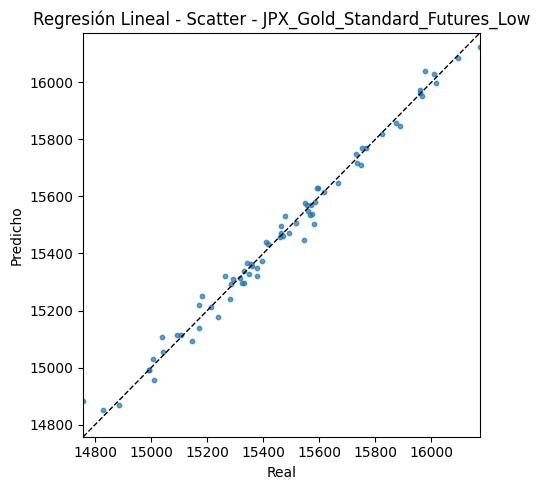

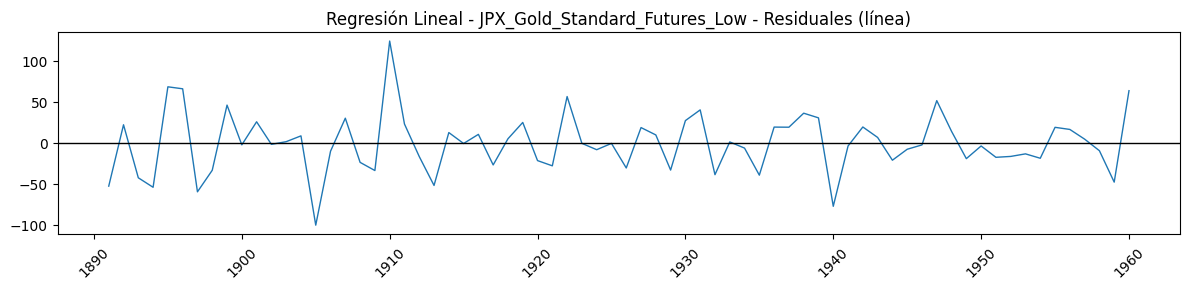

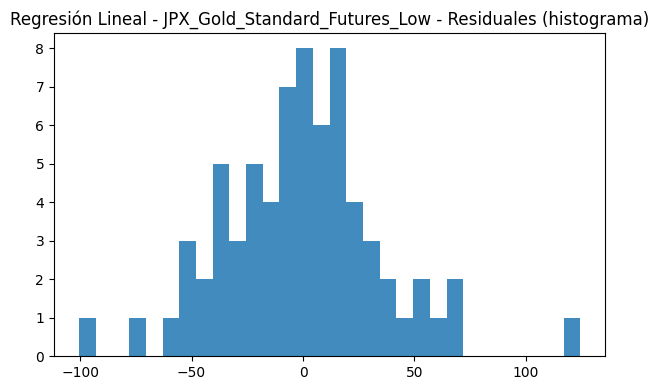


--- Linear Regression para: JPX_Gold_Standard_Futures_Open ---
[JPX_Gold_Standard_Futures_Open] MAE=35.1935  MSE=2380.3665  RMSE=48.7890


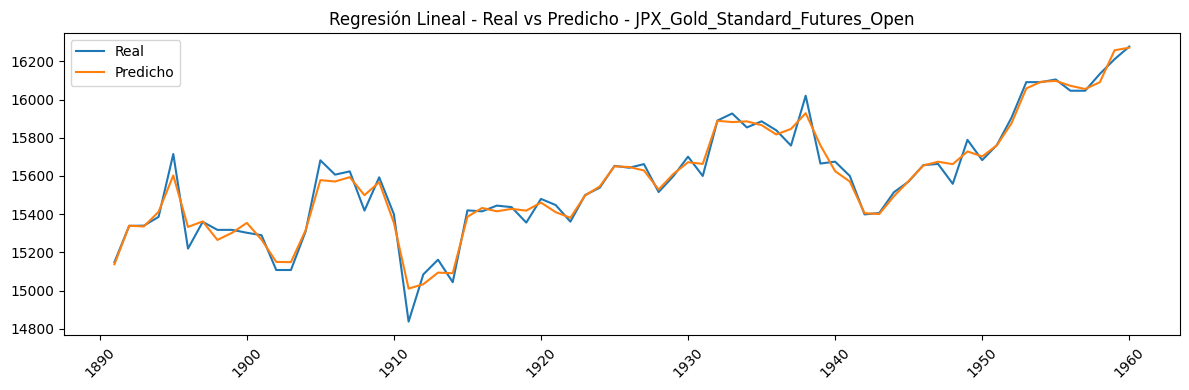

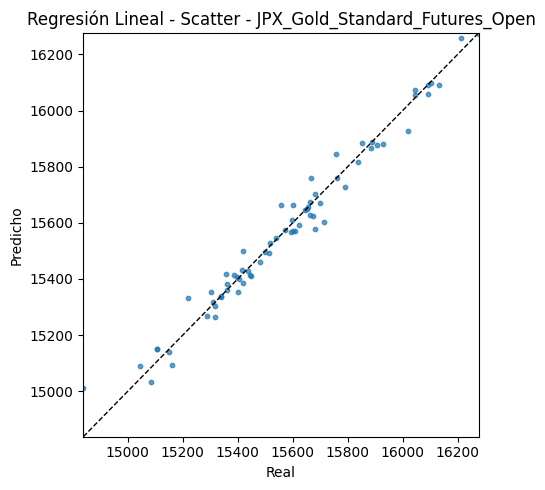

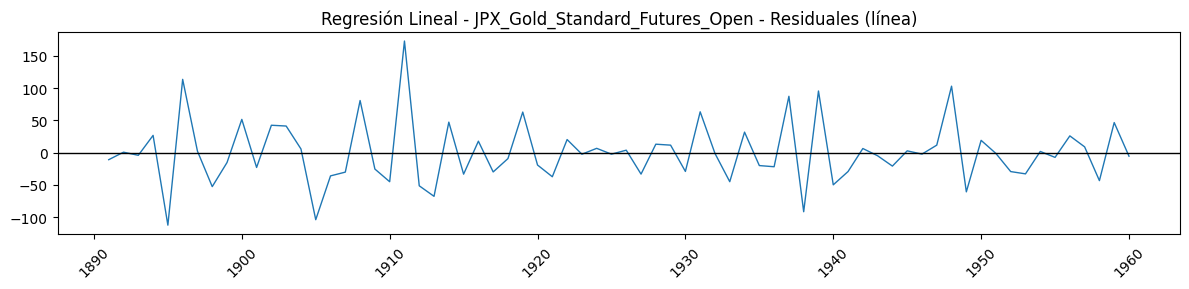

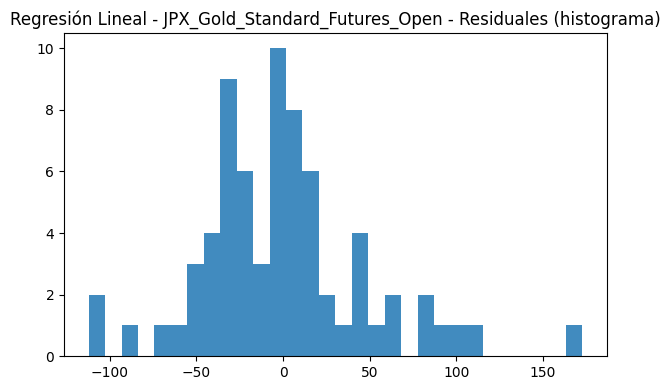


--- Linear Regression para: JPX_Gold_Mini_Futures_settlement_price ---
[JPX_Gold_Mini_Futures_settlement_price] MAE=38.1345  MSE=2730.8401  RMSE=52.2574


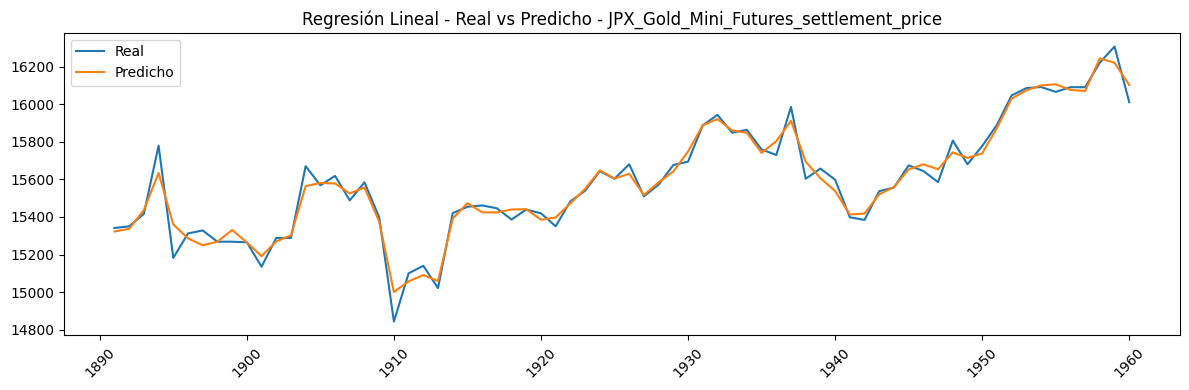

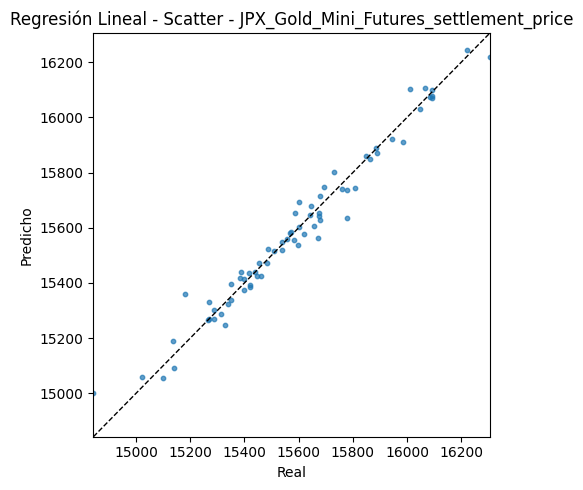

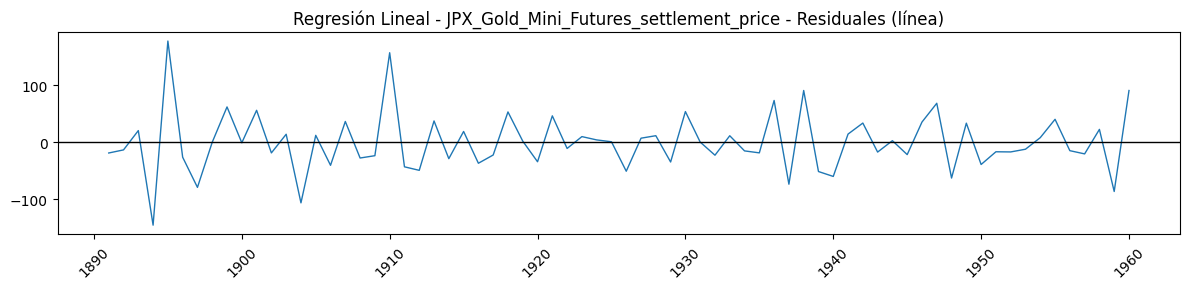

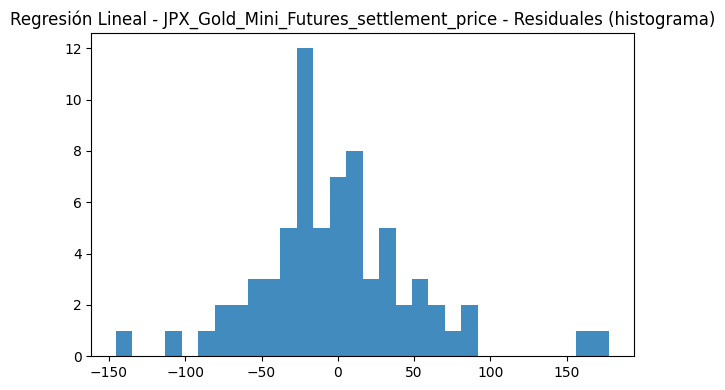


--- Linear Regression para: JPX_Gold_Mini_Futures_High ---
[JPX_Gold_Mini_Futures_High] MAE=29.2266  MSE=1551.5981  RMSE=39.3903


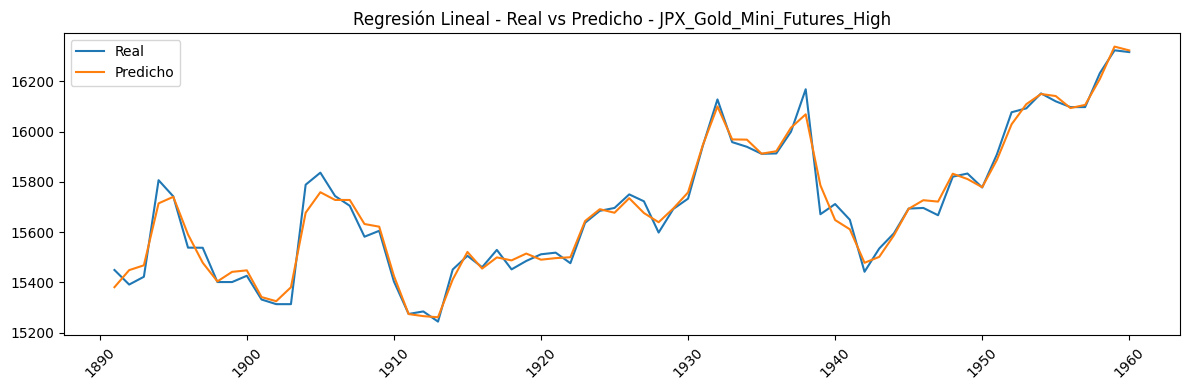

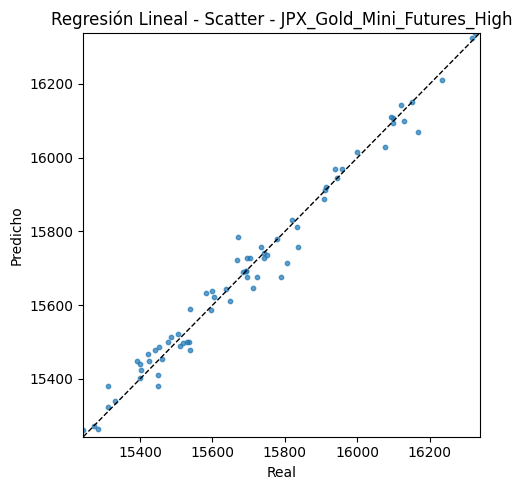

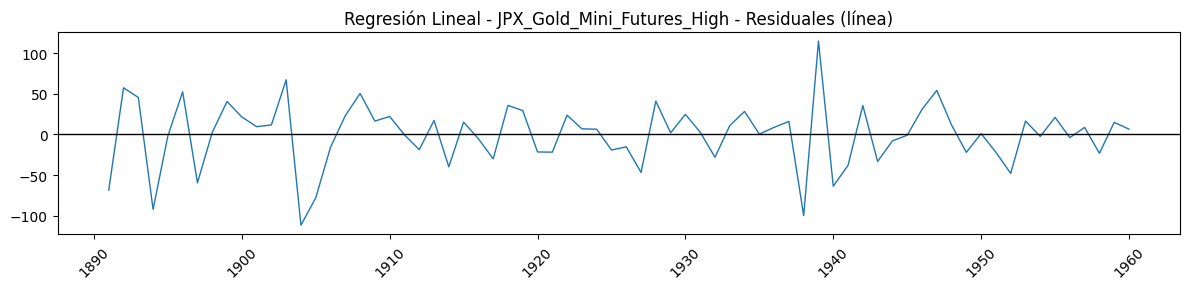

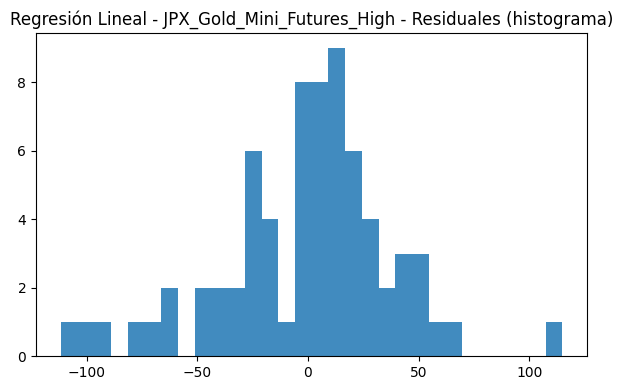


--- Linear Regression para: JPX_Gold_Mini_Futures_Low ---
[JPX_Gold_Mini_Futures_Low] MAE=27.3988  MSE=1296.1169  RMSE=36.0016


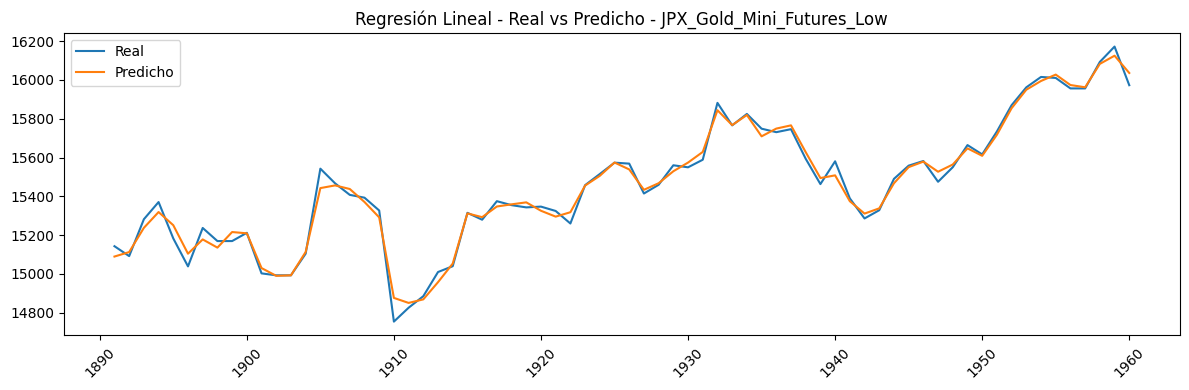

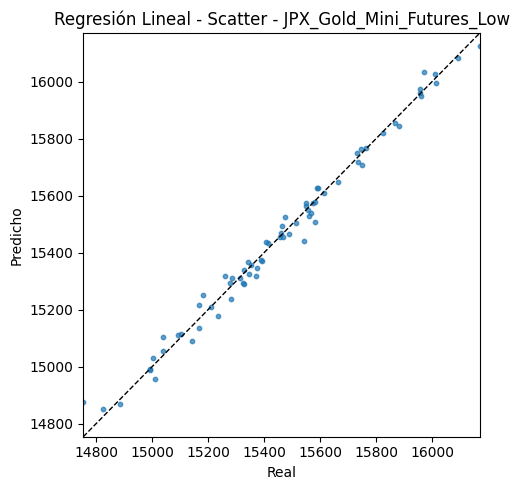

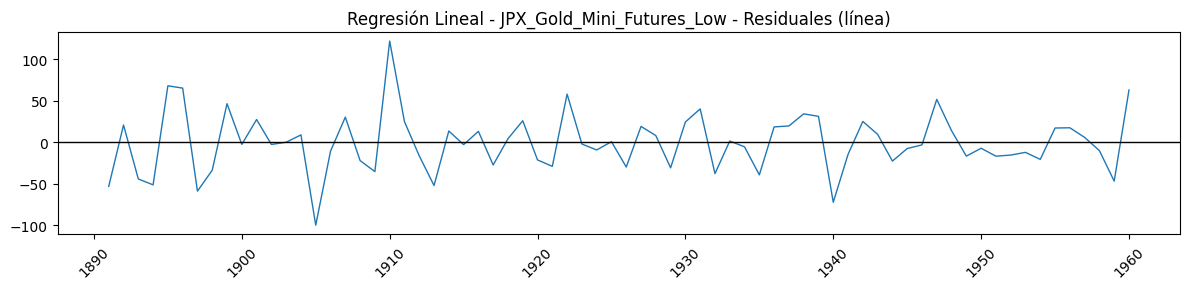

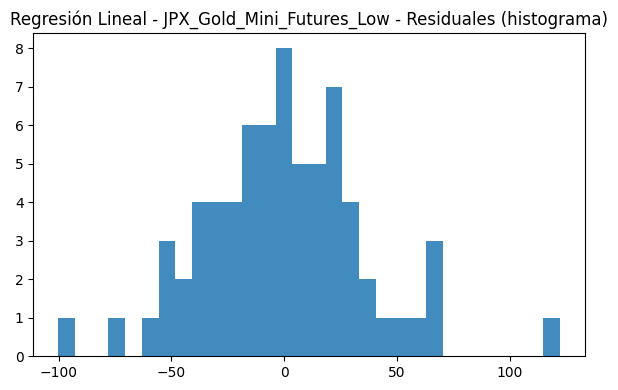


--- Linear Regression para: JPX_Gold_Mini_Futures_Close ---
[JPX_Gold_Mini_Futures_Close] MAE=37.7834  MSE=2652.1296  RMSE=51.4988


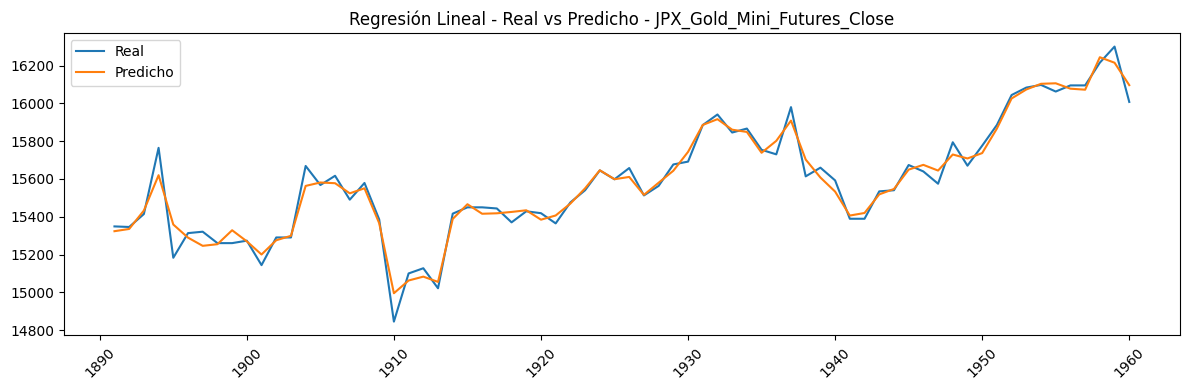

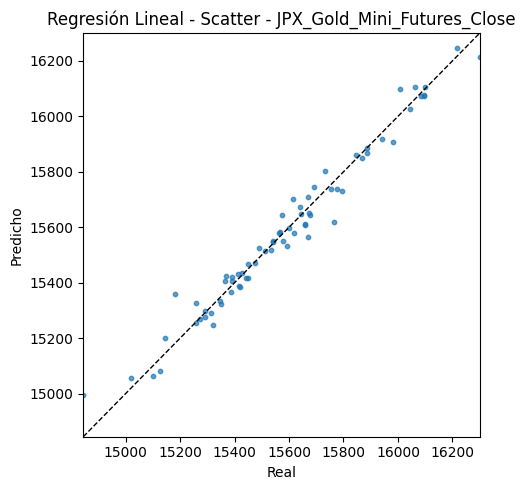

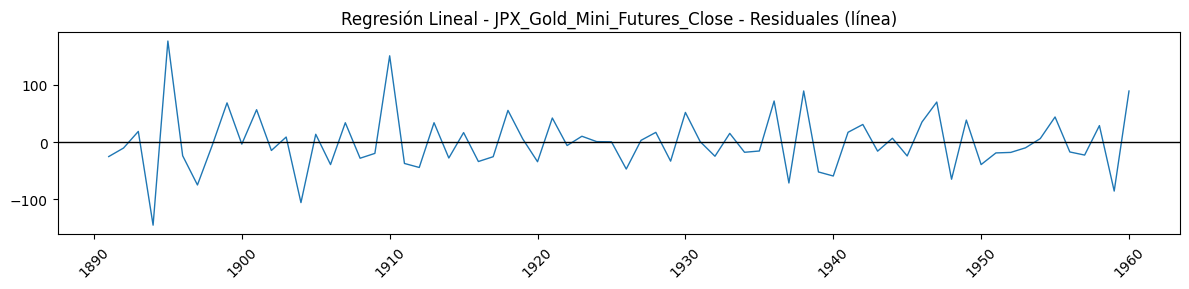

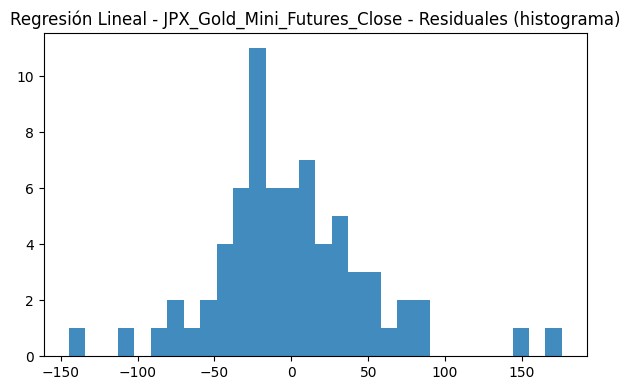


--- Linear Regression para: JPX_Gold_Mini_Futures_Open ---
[JPX_Gold_Mini_Futures_Open] MAE=35.6973  MSE=2394.2825  RMSE=48.9314


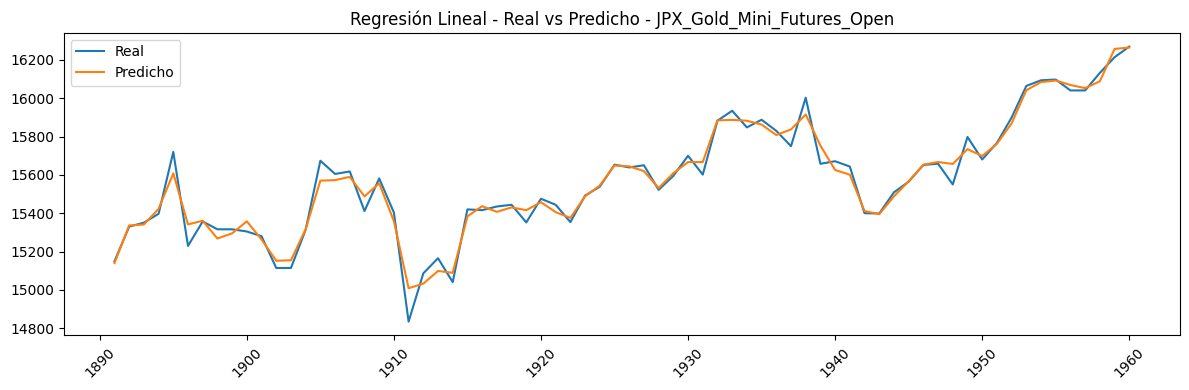

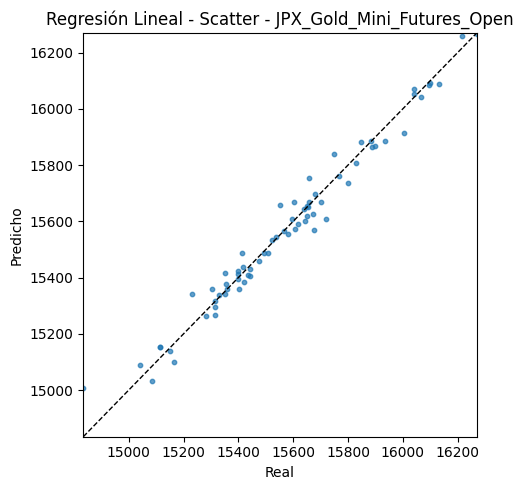

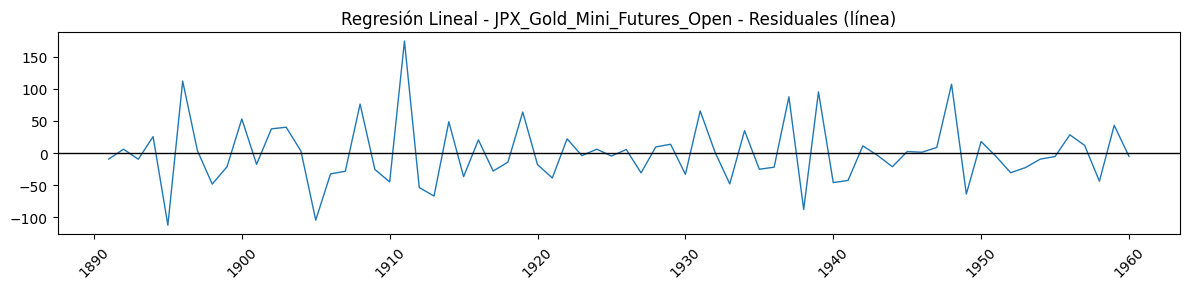

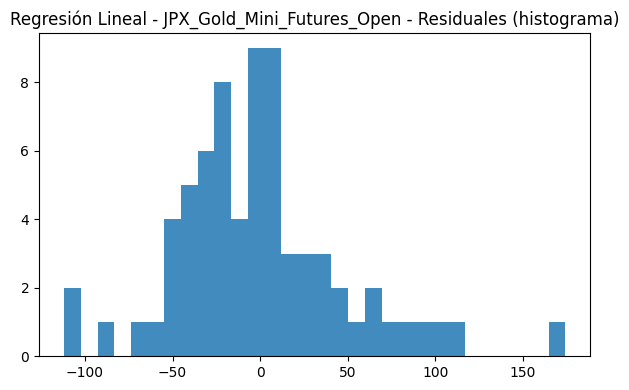

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("\n=== Regresión Lineal (ventanas) ===")
lin_results = []

for tcol in ALL_TARGETS:
    print(f"\n--- Linear Regression para: {tcol} ---")

    y_scaler = MinMaxScaler()
    y_tr = y_scaler.fit_transform(train_df[[tcol]].values)
    y_te = y_scaler.transform(test_df[[tcol]].values)

    Xtr, ytr = make_sequences(X_train_all, y_tr, LOOKBACK)
    Xte, yte = make_sequences(X_test_all,  y_te, LOOKBACK)

    Btr, T, F = Xtr.shape
    Xtr_flat = Xtr.reshape(Btr, T * F)
    Xte_flat = Xte.reshape(Xte.shape[0], T * F)

    lr = LinearRegression()
    lr.fit(Xtr_flat, ytr.ravel())
    yhat_scaled = lr.predict(Xte_flat).reshape(-1, 1)

    yhat_inv = y_scaler.inverse_transform(yhat_scaled)
    yte_inv  = y_scaler.inverse_transform(yte)

    mae  = mean_absolute_error(yte_inv, yhat_inv)
    mse  = mean_squared_error(yte_inv, yhat_inv)
    rmse = np.sqrt(mse)
    print(f"[{tcol}] MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")
    lin_results.append(("Linear", tcol, float(mae), float(mse), float(rmse)))

    y_true_1d = yte_inv.ravel()
    y_pred_1d = yhat_inv.ravel()
    plot_series(test_dates, y_true_1d, y_pred_1d, f"Regresión Lineal - Real vs Predicho - {tcol}")
    plot_scatter(y_true_1d, y_pred_1d, f"Regresión Lineal - Scatter - {tcol}")
    plot_residuals(test_dates, (y_pred_1d - y_true_1d), f"Regresión Lineal - {tcol}")



=== LSTM (PyTorch) ===

--- LSTM para: JPX_Gold_Standard_Futures_Close ---
Época 001/120 - Train MSE: 0.020254 (best 0.020254)
Época 005/120 - Train MSE: 0.000477 (best 0.000442)
Época 010/120 - Train MSE: 0.000310 (best 0.000294)
Época 015/120 - Train MSE: 0.000300 (best 0.000234)
Época 020/120 - Train MSE: 0.000194 (best 0.000194)
Época 025/120 - Train MSE: 0.000172 (best 0.000154)
Época 030/120 - Train MSE: 0.000107 (best 0.000102)
Época 035/120 - Train MSE: 0.000115 (best 0.000102)
Época 040/120 - Train MSE: 0.000174 (best 0.000089)
Época 045/120 - Train MSE: 0.000092 (best 0.000089)
Época 050/120 - Train MSE: 0.000104 (best 0.000077)
Época 055/120 - Train MSE: 0.000102 (best 0.000077)
Época 060/120 - Train MSE: 0.000086 (best 0.000077)
Época 065/120 - Train MSE: 0.000079 (best 0.000077)
Época 070/120 - Train MSE: 0.000055 (best 0.000055)
Época 075/120 - Train MSE: 0.000065 (best 0.000055)
Época 080/120 - Train MSE: 0.000058 (best 0.000055)
Época 085/120 - Train MSE: 0.000053 (bes

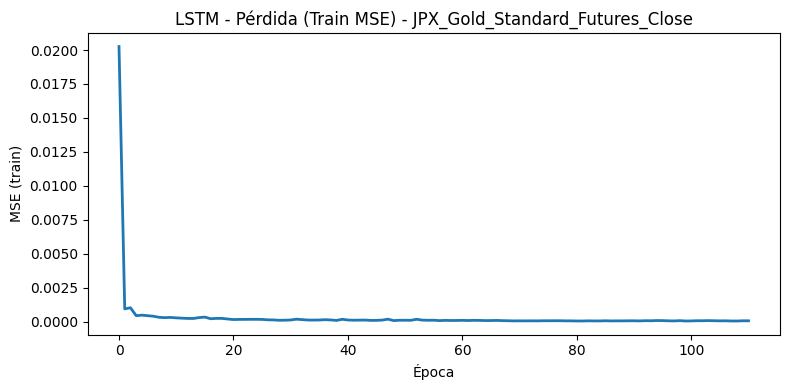

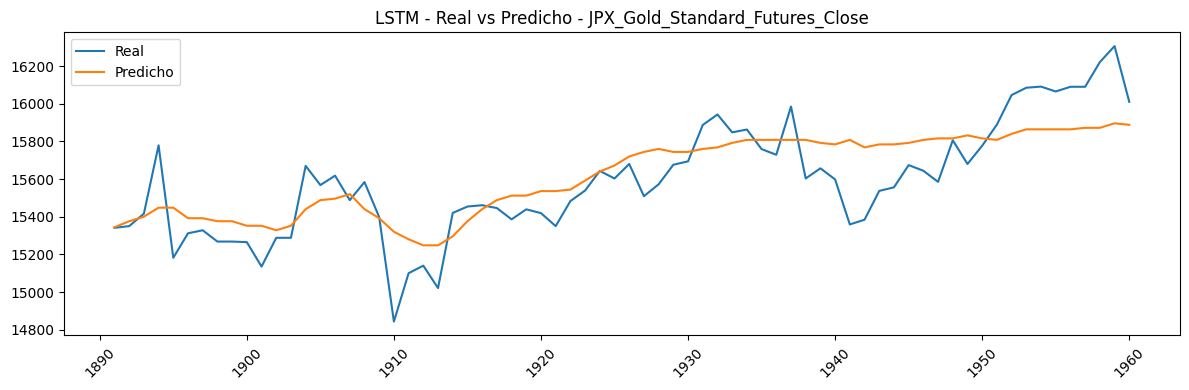

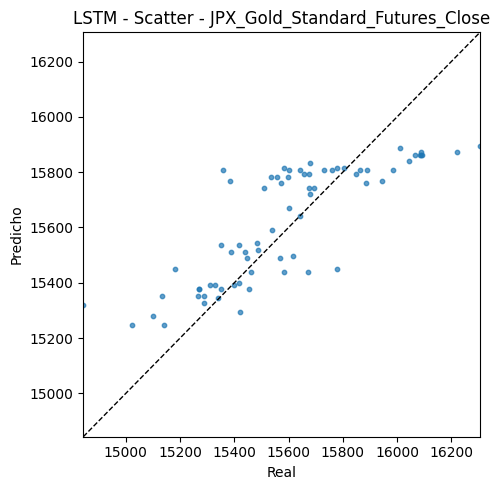

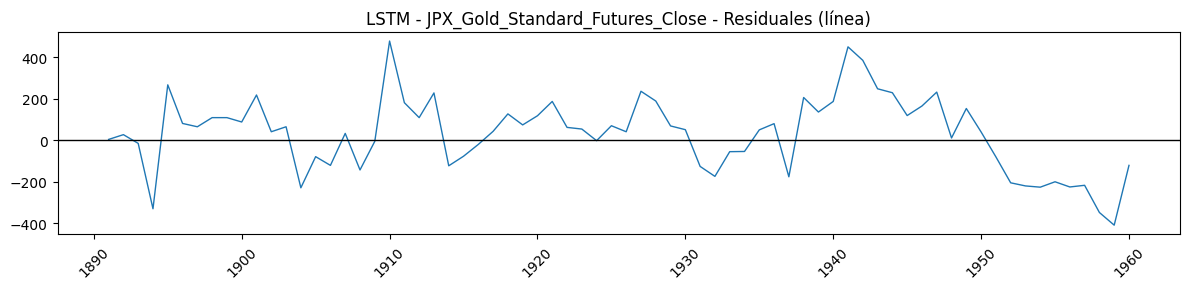

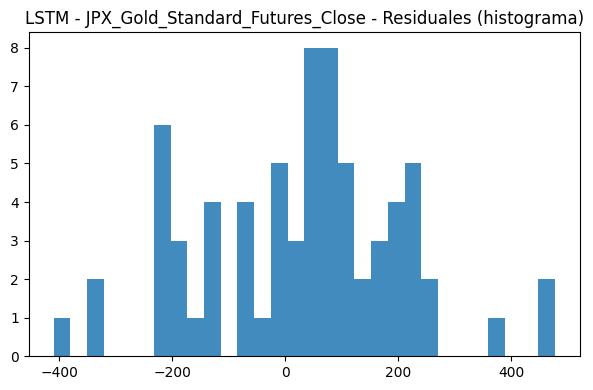


--- LSTM para: JPX_Gold_Standard_Futures_High ---
Época 001/120 - Train MSE: 0.025523 (best 0.025523)
Época 005/120 - Train MSE: 0.001039 (best 0.000601)
Época 010/120 - Train MSE: 0.000504 (best 0.000301)
Época 015/120 - Train MSE: 0.000258 (best 0.000191)
Época 020/120 - Train MSE: 0.000149 (best 0.000149)
Época 025/120 - Train MSE: 0.000143 (best 0.000110)
Época 030/120 - Train MSE: 0.000100 (best 0.000099)
Época 035/120 - Train MSE: 0.000092 (best 0.000092)
Época 040/120 - Train MSE: 0.000084 (best 0.000084)
Época 045/120 - Train MSE: 0.000111 (best 0.000084)
Época 050/120 - Train MSE: 0.000077 (best 0.000075)
Época 055/120 - Train MSE: 0.000111 (best 0.000075)
Época 060/120 - Train MSE: 0.000087 (best 0.000075)
Época 065/120 - Train MSE: 0.000132 (best 0.000060)
Época 070/120 - Train MSE: 0.000124 (best 0.000060)
Época 075/120 - Train MSE: 0.000063 (best 0.000060)
Época 080/120 - Train MSE: 0.000073 (best 0.000060)
Época 085/120 - Train MSE: 0.000095 (best 0.000060)
Época 090/120

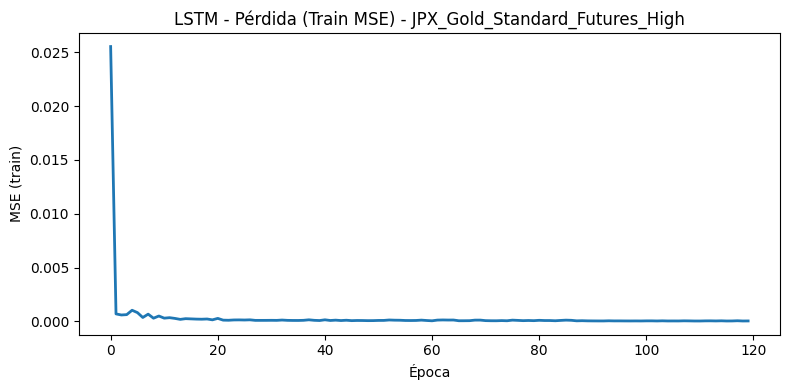

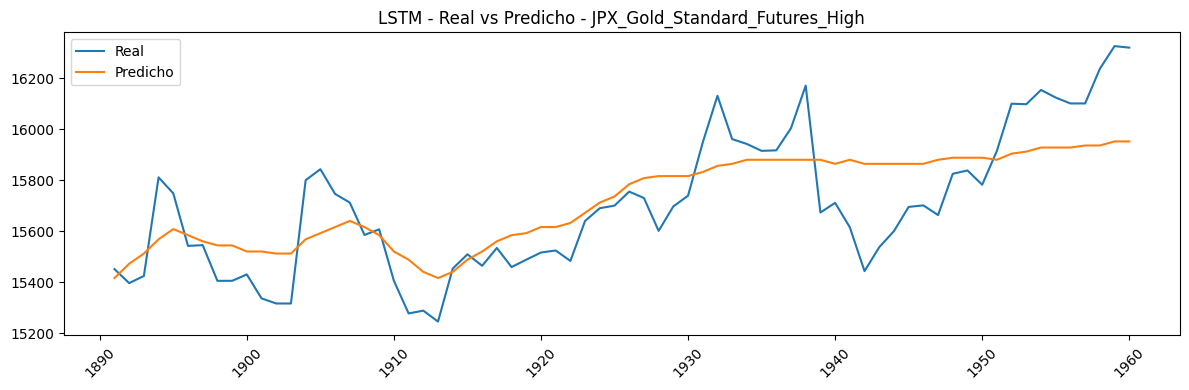

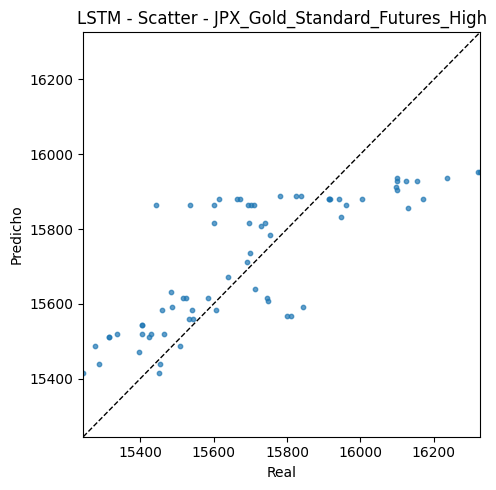

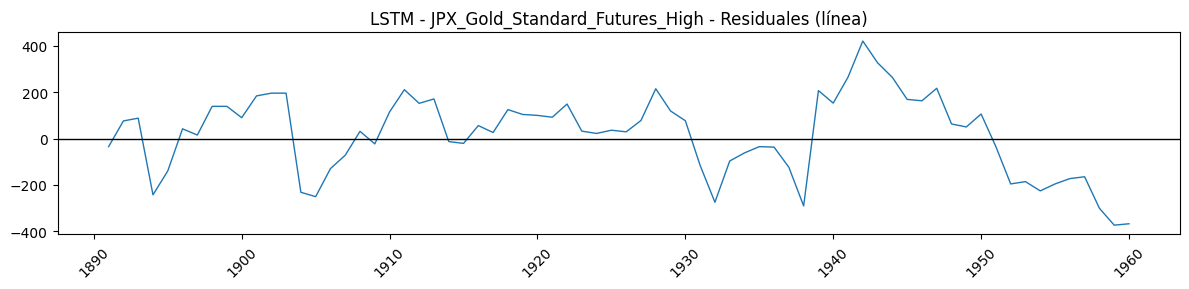

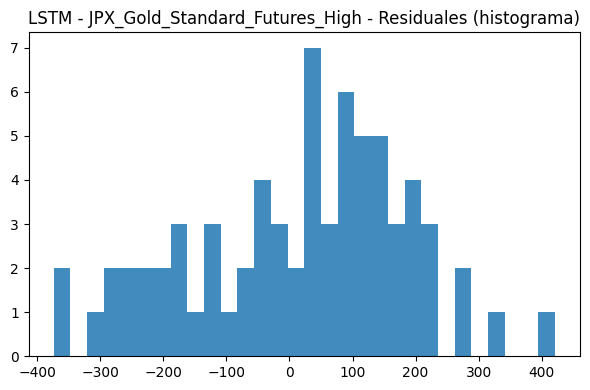


--- LSTM para: JPX_Gold_Standard_Futures_Low ---
Época 001/120 - Train MSE: 0.035431 (best 0.035431)
Época 005/120 - Train MSE: 0.000371 (best 0.000371)
Época 010/120 - Train MSE: 0.000404 (best 0.000287)
Época 015/120 - Train MSE: 0.000325 (best 0.000230)
Época 020/120 - Train MSE: 0.000355 (best 0.000210)
Época 025/120 - Train MSE: 0.000294 (best 0.000150)
Época 030/120 - Train MSE: 0.000157 (best 0.000150)
Época 035/120 - Train MSE: 0.000235 (best 0.000116)
Época 040/120 - Train MSE: 0.000104 (best 0.000105)
Época 045/120 - Train MSE: 0.000131 (best 0.000103)
Época 050/120 - Train MSE: 0.000089 (best 0.000083)
Época 055/120 - Train MSE: 0.000094 (best 0.000083)
Época 060/120 - Train MSE: 0.000089 (best 0.000076)
Época 065/120 - Train MSE: 0.000109 (best 0.000076)
Época 070/120 - Train MSE: 0.000081 (best 0.000071)
Época 075/120 - Train MSE: 0.000075 (best 0.000071)
Época 080/120 - Train MSE: 0.000079 (best 0.000071)
Época 085/120 - Train MSE: 0.000065 (best 0.000065)
Época 090/120 

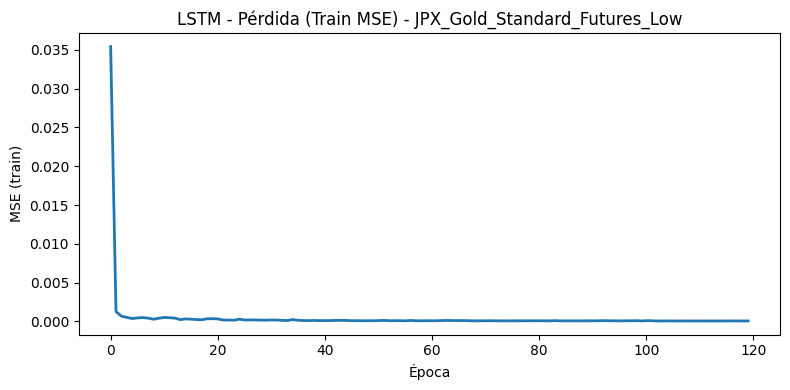

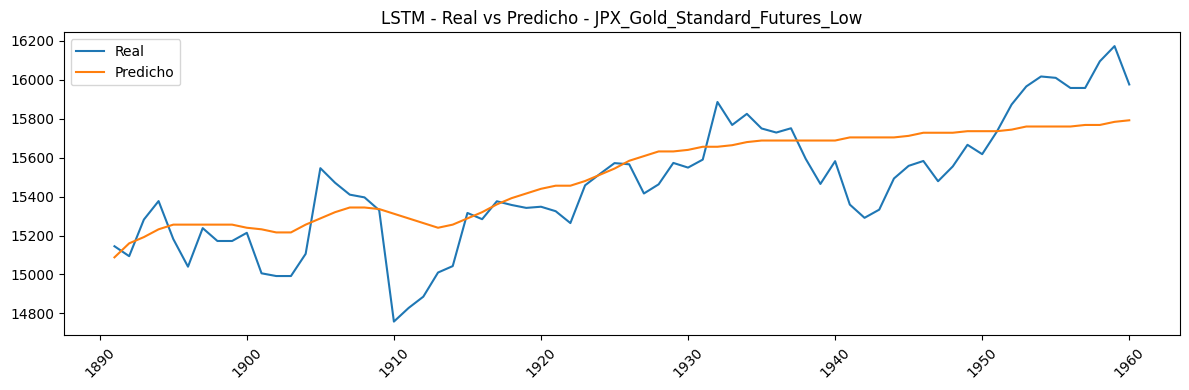

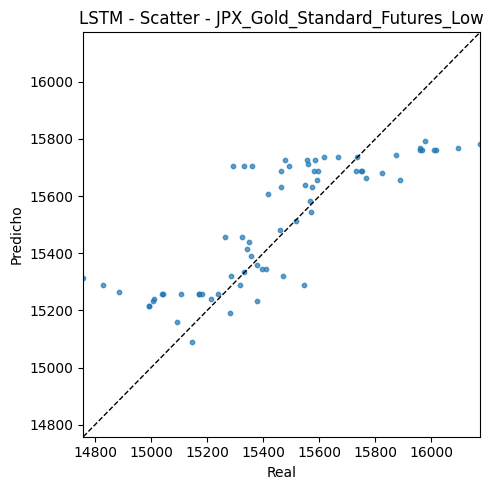

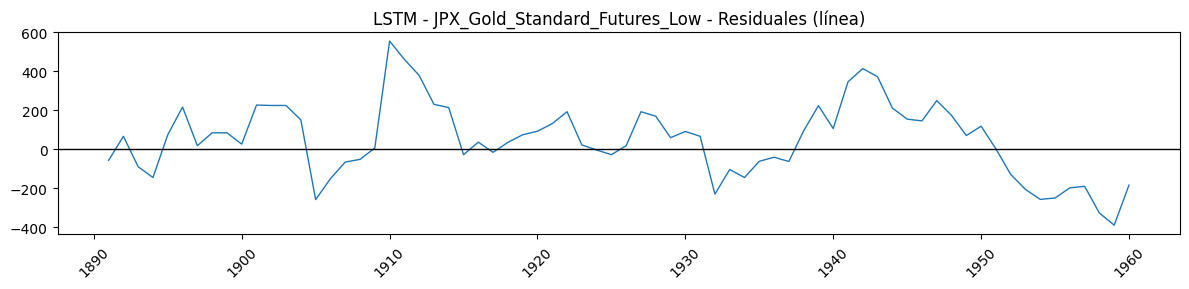

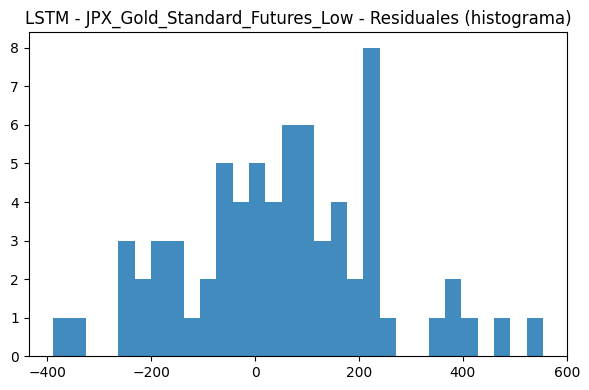


--- LSTM para: JPX_Gold_Standard_Futures_Open ---
Época 001/120 - Train MSE: 0.046799 (best 0.046799)
Época 005/120 - Train MSE: 0.000448 (best 0.000448)
Época 010/120 - Train MSE: 0.000307 (best 0.000285)
Época 015/120 - Train MSE: 0.000396 (best 0.000280)
Época 020/120 - Train MSE: 0.000202 (best 0.000161)
Época 025/120 - Train MSE: 0.000190 (best 0.000161)
Época 030/120 - Train MSE: 0.000146 (best 0.000133)
Época 035/120 - Train MSE: 0.000152 (best 0.000133)
Época 040/120 - Train MSE: 0.000107 (best 0.000107)
Época 045/120 - Train MSE: 0.000126 (best 0.000107)
Época 050/120 - Train MSE: 0.000086 (best 0.000086)
Época 055/120 - Train MSE: 0.000156 (best 0.000086)
Época 060/120 - Train MSE: 0.000115 (best 0.000082)
Época 065/120 - Train MSE: 0.000076 (best 0.000076)
Época 070/120 - Train MSE: 0.000069 (best 0.000069)
Época 075/120 - Train MSE: 0.000063 (best 0.000061)
Época 080/120 - Train MSE: 0.000068 (best 0.000056)
Época 085/120 - Train MSE: 0.000061 (best 0.000056)
Época 090/120

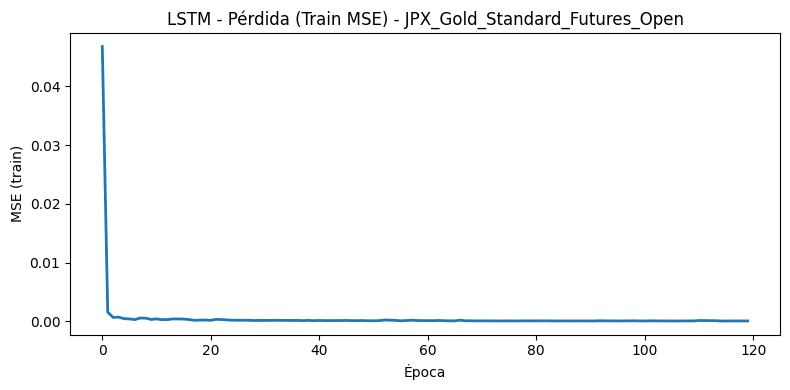

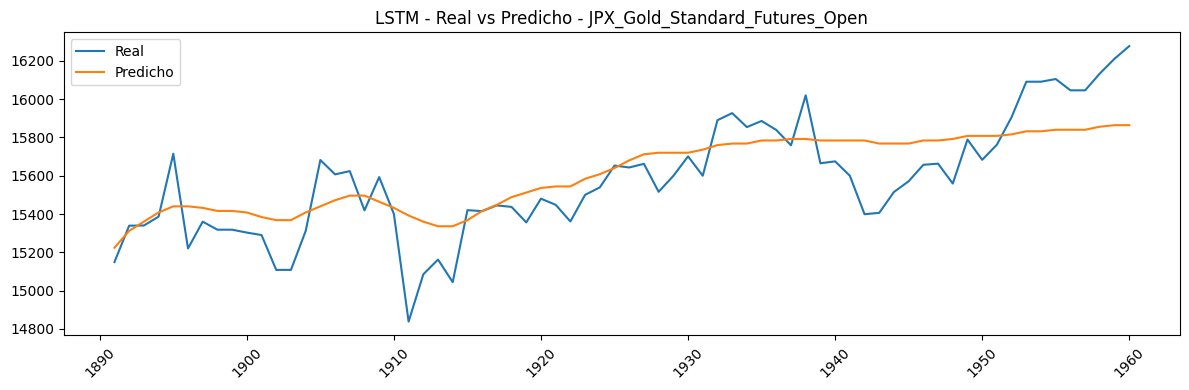

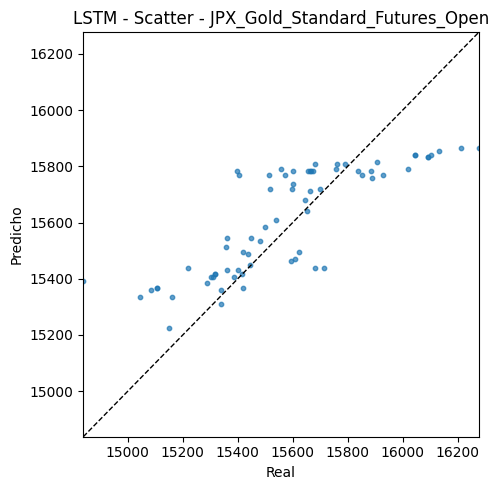

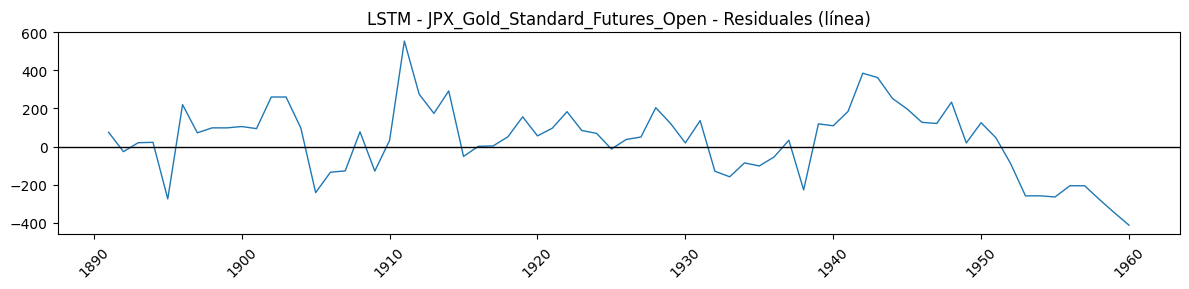

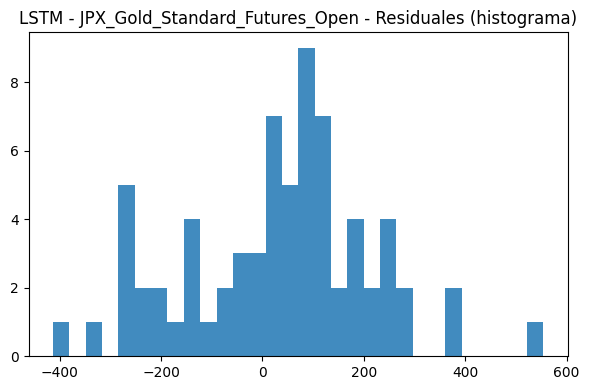


--- LSTM para: JPX_Gold_Mini_Futures_settlement_price ---
Época 001/120 - Train MSE: 0.032765 (best 0.032765)
Época 005/120 - Train MSE: 0.000342 (best 0.000342)
Época 010/120 - Train MSE: 0.000509 (best 0.000342)
Época 015/120 - Train MSE: 0.000238 (best 0.000238)
Época 020/120 - Train MSE: 0.000184 (best 0.000184)
Época 025/120 - Train MSE: 0.000205 (best 0.000159)
Época 030/120 - Train MSE: 0.000119 (best 0.000119)
Época 035/120 - Train MSE: 0.000116 (best 0.000116)
Época 040/120 - Train MSE: 0.000159 (best 0.000116)
Época 045/120 - Train MSE: 0.000117 (best 0.000115)
Época 050/120 - Train MSE: 0.000153 (best 0.000115)
Época 055/120 - Train MSE: 0.000110 (best 0.000096)
Época 060/120 - Train MSE: 0.000091 (best 0.000091)
Época 065/120 - Train MSE: 0.000180 (best 0.000091)
Época 070/120 - Train MSE: 0.000087 (best 0.000069)
Época 075/120 - Train MSE: 0.000062 (best 0.000062)
Época 080/120 - Train MSE: 0.000079 (best 0.000062)
Época 085/120 - Train MSE: 0.000070 (best 0.000058)
Época

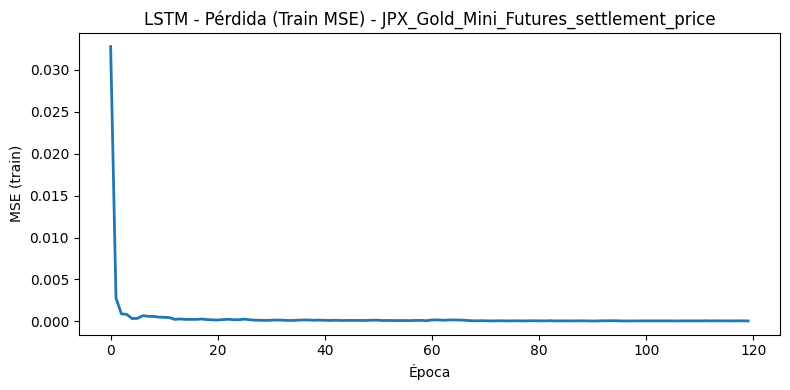

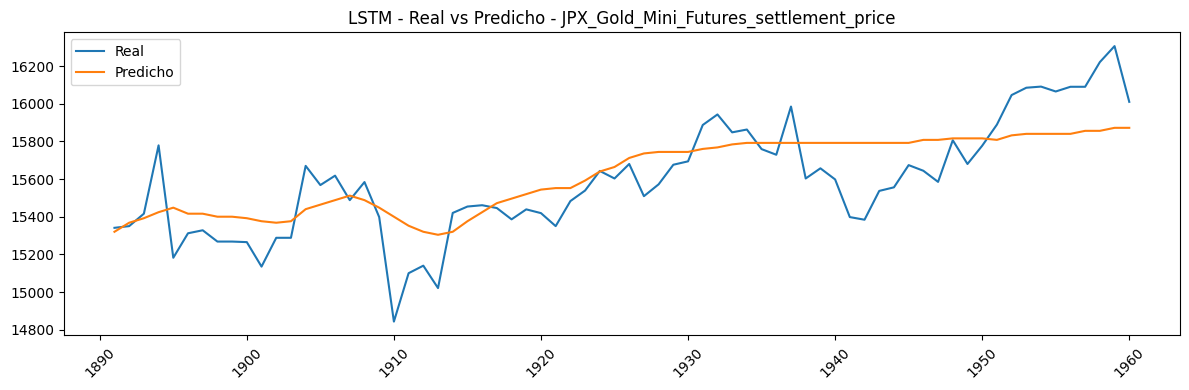

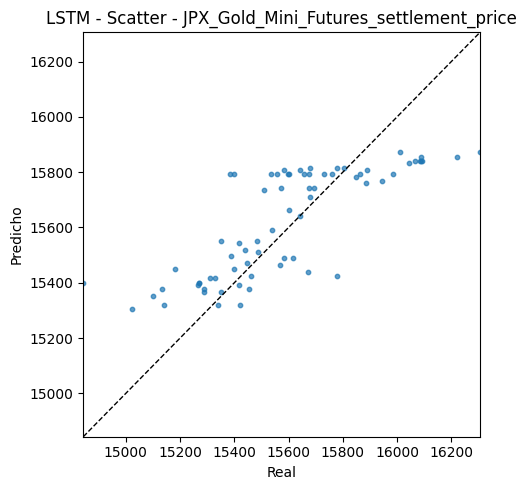

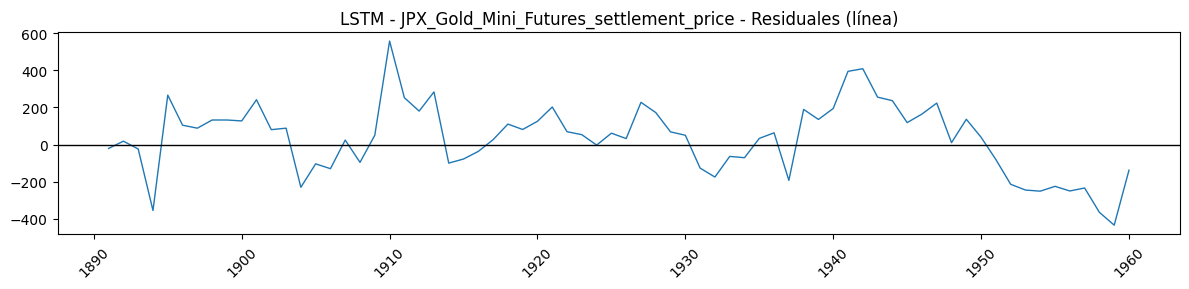

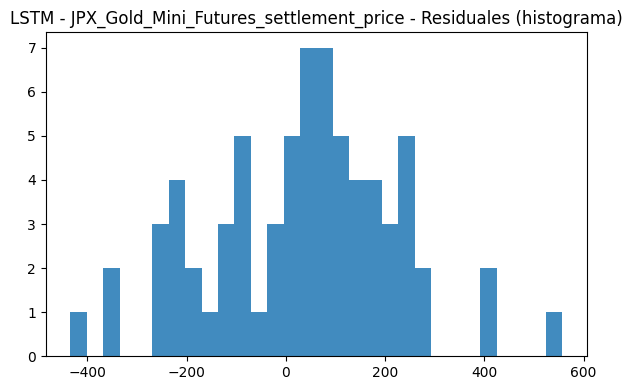


--- LSTM para: JPX_Gold_Mini_Futures_High ---
Época 001/120 - Train MSE: 0.037556 (best 0.037556)
Época 005/120 - Train MSE: 0.000393 (best 0.000393)
Época 010/120 - Train MSE: 0.000310 (best 0.000310)
Época 015/120 - Train MSE: 0.000182 (best 0.000182)
Época 020/120 - Train MSE: 0.000159 (best 0.000153)
Época 025/120 - Train MSE: 0.000170 (best 0.000153)
Época 030/120 - Train MSE: 0.000154 (best 0.000132)
Época 035/120 - Train MSE: 0.000126 (best 0.000123)
Época 040/120 - Train MSE: 0.000115 (best 0.000111)
Época 045/120 - Train MSE: 0.000112 (best 0.000111)
Época 050/120 - Train MSE: 0.000117 (best 0.000094)
Época 055/120 - Train MSE: 0.000136 (best 0.000094)
Época 060/120 - Train MSE: 0.000146 (best 0.000094)
Época 065/120 - Train MSE: 0.000119 (best 0.000094)
Época 070/120 - Train MSE: 0.000108 (best 0.000094)
Época 075/120 - Train MSE: 0.000102 (best 0.000081)
Época 080/120 - Train MSE: 0.000085 (best 0.000081)
Época 085/120 - Train MSE: 0.000077 (best 0.000067)
Época 090/120 - T

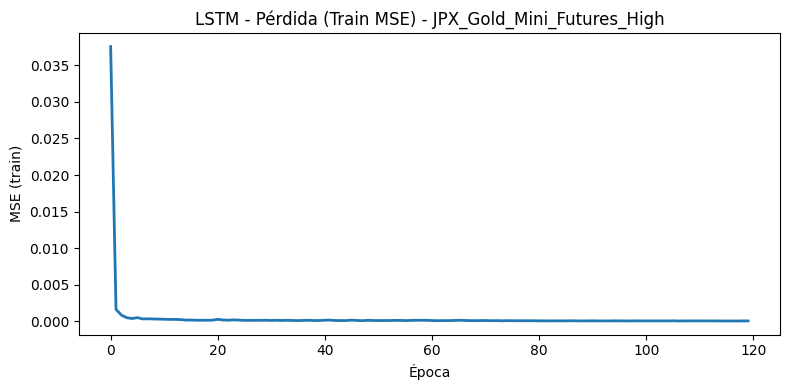

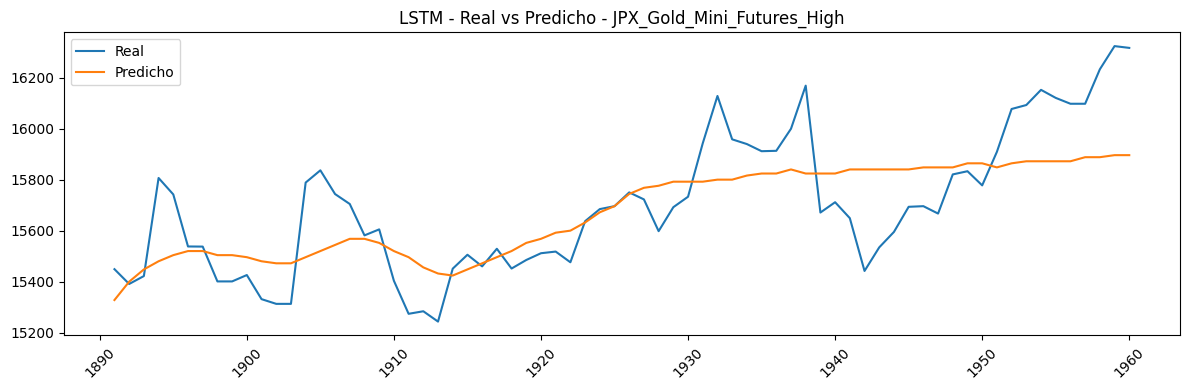

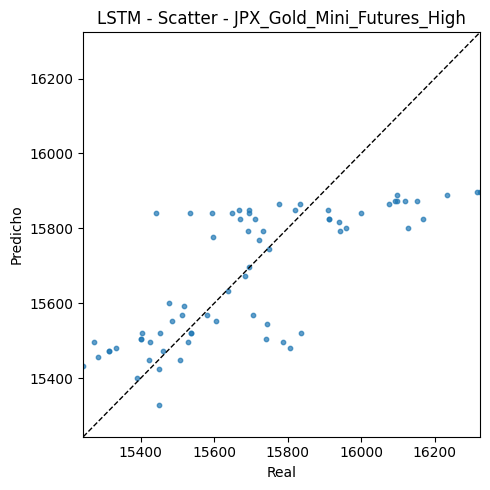

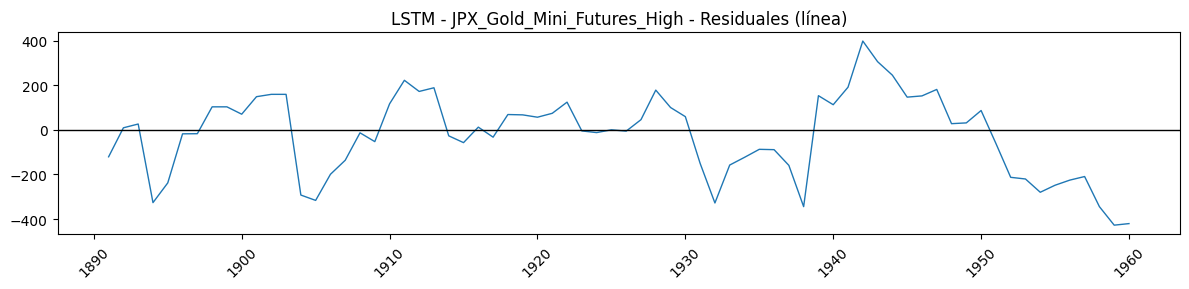

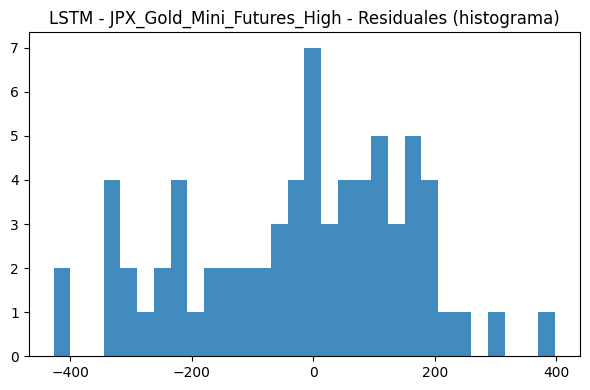


--- LSTM para: JPX_Gold_Mini_Futures_Low ---
Época 001/120 - Train MSE: 0.042762 (best 0.042762)
Época 005/120 - Train MSE: 0.000411 (best 0.000411)
Época 010/120 - Train MSE: 0.000333 (best 0.000325)
Época 015/120 - Train MSE: 0.000209 (best 0.000209)
Época 020/120 - Train MSE: 0.000205 (best 0.000152)
Época 025/120 - Train MSE: 0.000180 (best 0.000152)
Época 030/120 - Train MSE: 0.000196 (best 0.000152)
Época 035/120 - Train MSE: 0.000280 (best 0.000117)
Época 040/120 - Train MSE: 0.000101 (best 0.000101)
Época 045/120 - Train MSE: 0.000176 (best 0.000101)
Época 050/120 - Train MSE: 0.000133 (best 0.000100)
Época 055/120 - Train MSE: 0.000119 (best 0.000100)
Época 060/120 - Train MSE: 0.000161 (best 0.000100)
Época 065/120 - Train MSE: 0.000086 (best 0.000086)
Época 070/120 - Train MSE: 0.000062 (best 0.000062)
Época 075/120 - Train MSE: 0.000057 (best 0.000057)
Época 080/120 - Train MSE: 0.000061 (best 0.000057)
Época 085/120 - Train MSE: 0.000058 (best 0.000054)
Época 090/120 - Tr

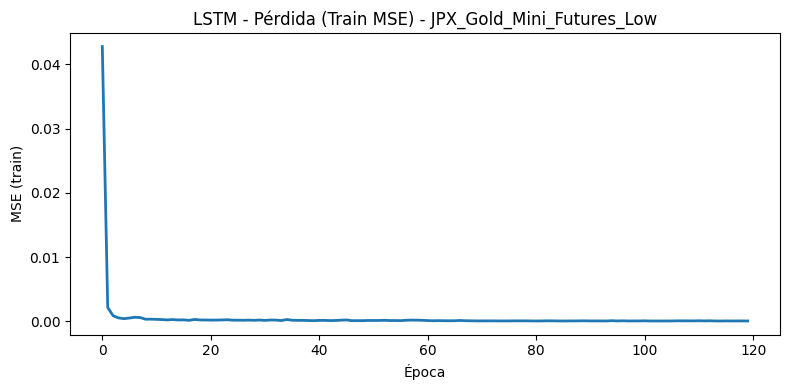

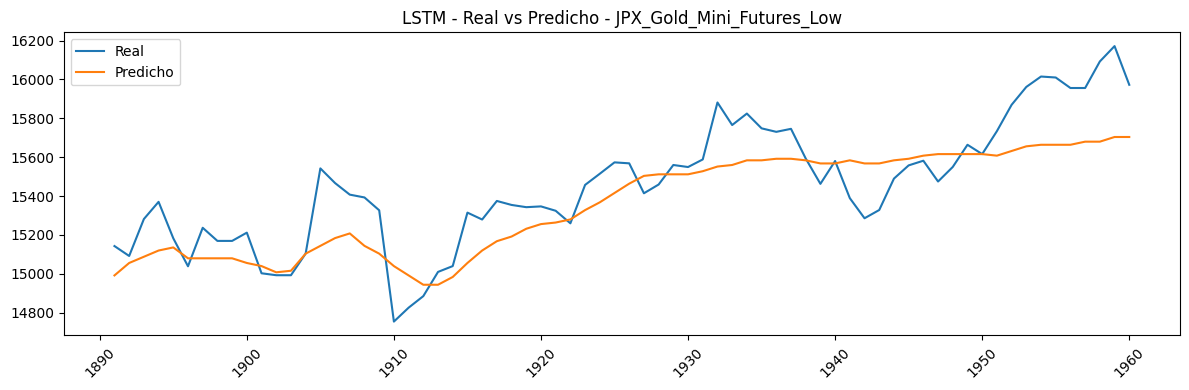

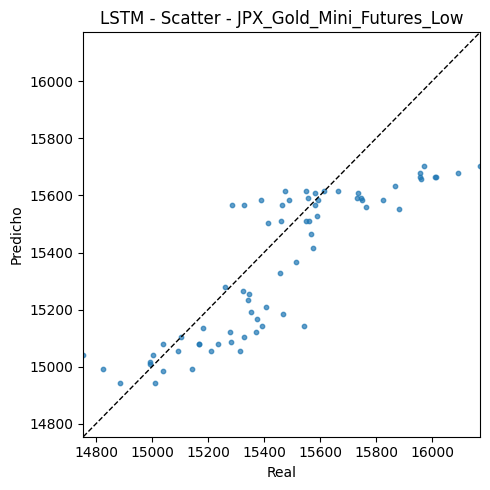

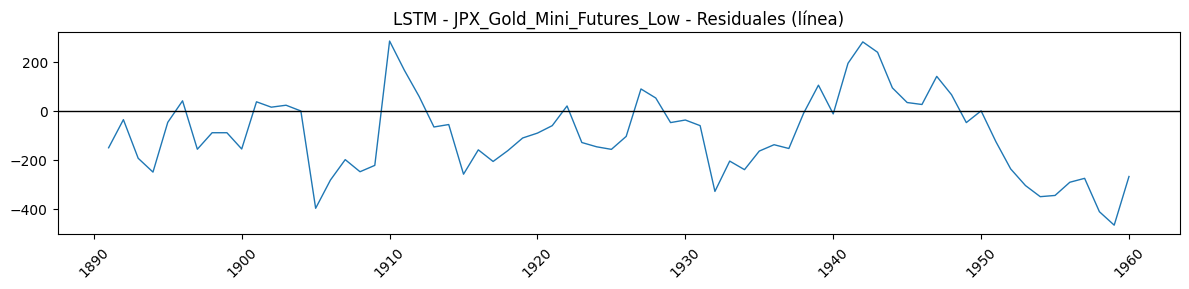

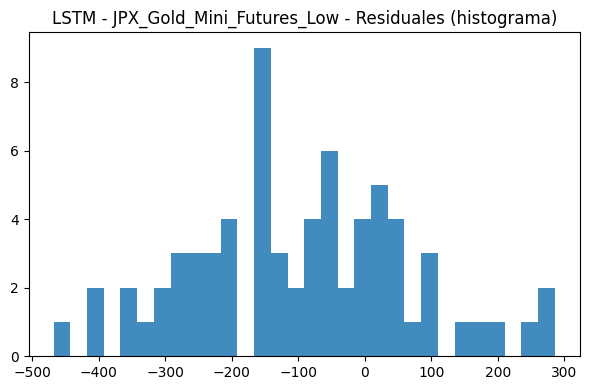


--- LSTM para: JPX_Gold_Mini_Futures_Close ---
Época 001/120 - Train MSE: 0.041405 (best 0.041405)
Época 005/120 - Train MSE: 0.000533 (best 0.000533)
Época 010/120 - Train MSE: 0.000290 (best 0.000290)
Época 015/120 - Train MSE: 0.000243 (best 0.000243)
Época 020/120 - Train MSE: 0.000192 (best 0.000183)
Época 025/120 - Train MSE: 0.000141 (best 0.000141)
Época 030/120 - Train MSE: 0.000220 (best 0.000141)
Época 035/120 - Train MSE: 0.000132 (best 0.000130)
Época 040/120 - Train MSE: 0.000136 (best 0.000120)
Época 045/120 - Train MSE: 0.000135 (best 0.000120)
Época 050/120 - Train MSE: 0.000123 (best 0.000105)
Época 055/120 - Train MSE: 0.000110 (best 0.000105)
Época 060/120 - Train MSE: 0.000156 (best 0.000105)
Época 065/120 - Train MSE: 0.000134 (best 0.000105)
Época 070/120 - Train MSE: 0.000109 (best 0.000105)
Época 075/120 - Train MSE: 0.000096 (best 0.000096)
Época 080/120 - Train MSE: 0.000118 (best 0.000096)
Época 085/120 - Train MSE: 0.000086 (best 0.000082)
Época 090/120 - 

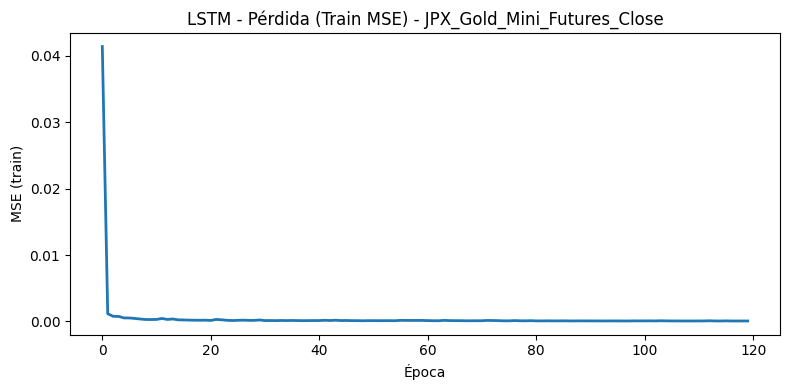

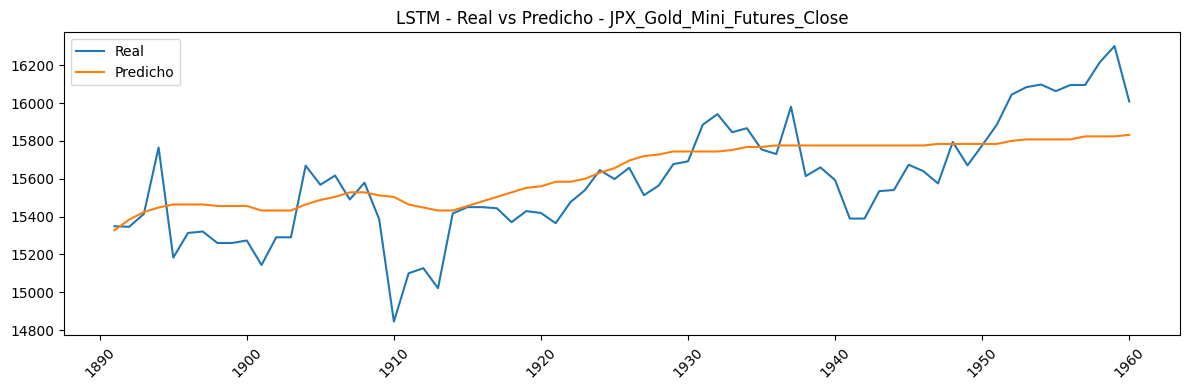

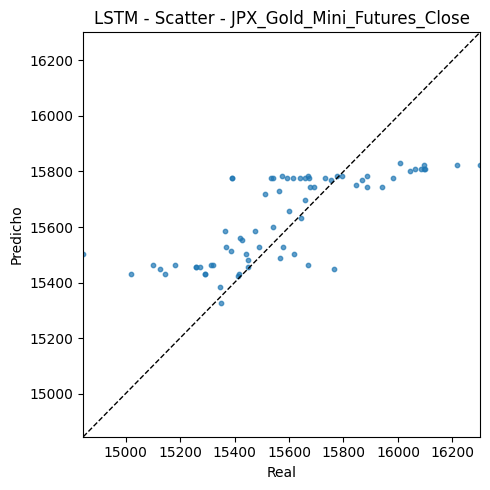

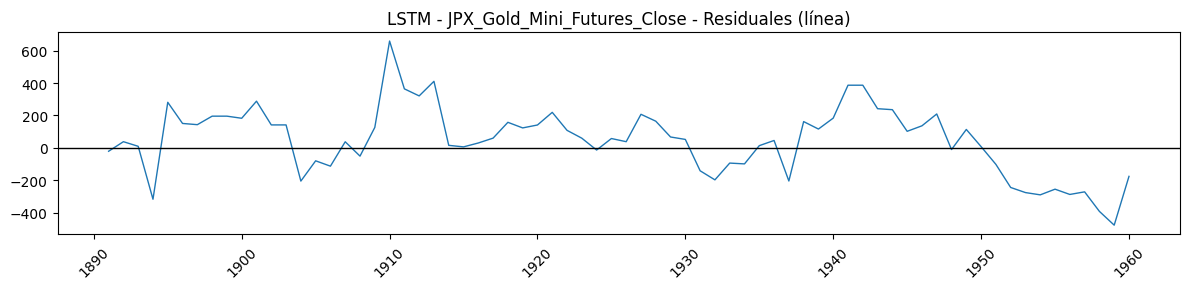

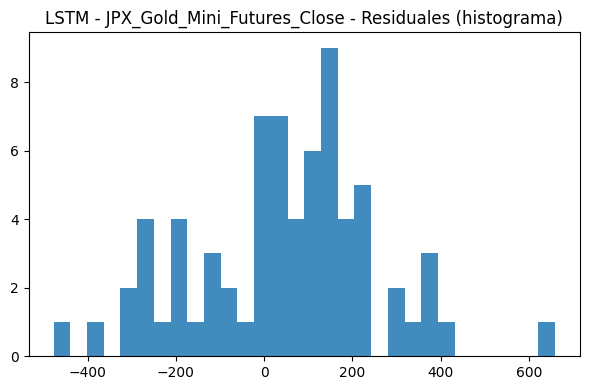


--- LSTM para: JPX_Gold_Mini_Futures_Open ---
Época 001/120 - Train MSE: 0.048386 (best 0.048386)
Época 005/120 - Train MSE: 0.000381 (best 0.000381)
Época 010/120 - Train MSE: 0.000261 (best 0.000261)
Época 015/120 - Train MSE: 0.000246 (best 0.000228)
Época 020/120 - Train MSE: 0.000179 (best 0.000155)
Época 025/120 - Train MSE: 0.000261 (best 0.000155)
Época 030/120 - Train MSE: 0.000168 (best 0.000147)
Época 035/120 - Train MSE: 0.000131 (best 0.000121)
Época 040/120 - Train MSE: 0.000155 (best 0.000121)
Época 045/120 - Train MSE: 0.000212 (best 0.000121)
Época 050/120 - Train MSE: 0.000134 (best 0.000101)
Época 055/120 - Train MSE: 0.000122 (best 0.000101)
Época 060/120 - Train MSE: 0.000078 (best 0.000078)
Época 065/120 - Train MSE: 0.000090 (best 0.000078)
Época 070/120 - Train MSE: 0.000087 (best 0.000072)
Época 075/120 - Train MSE: 0.000068 (best 0.000065)
Época 080/120 - Train MSE: 0.000062 (best 0.000059)
Época 085/120 - Train MSE: 0.000067 (best 0.000057)
Época 090/120 - T

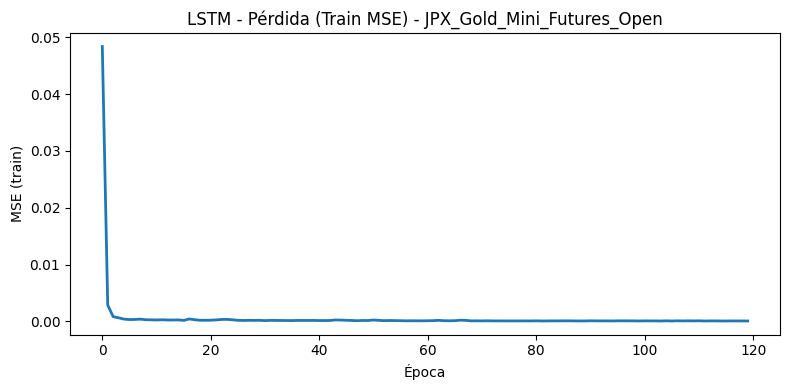

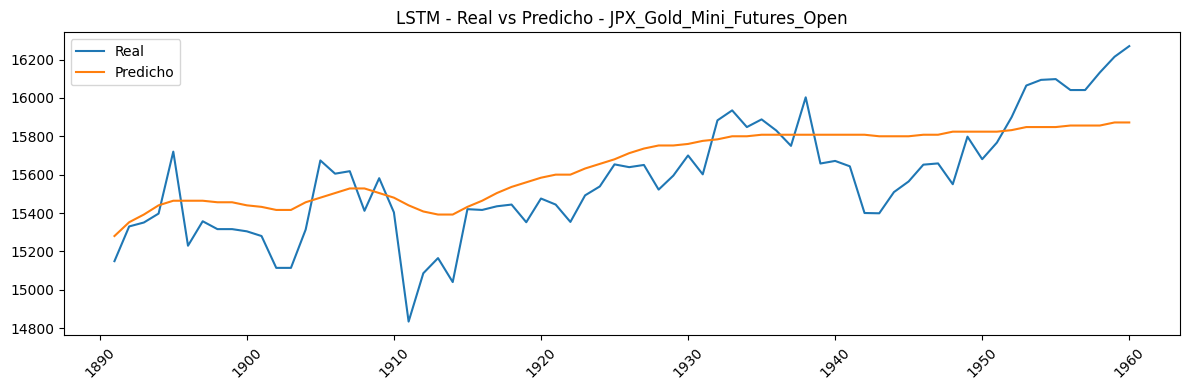

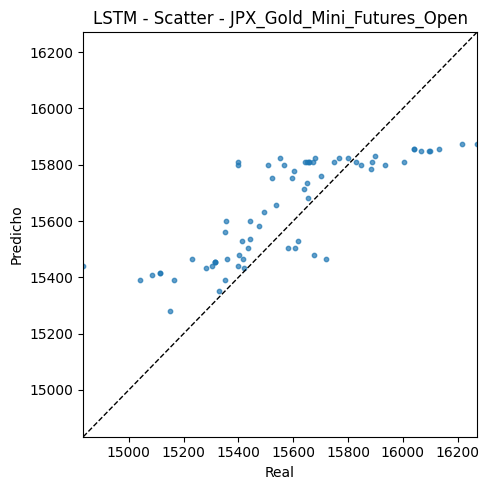

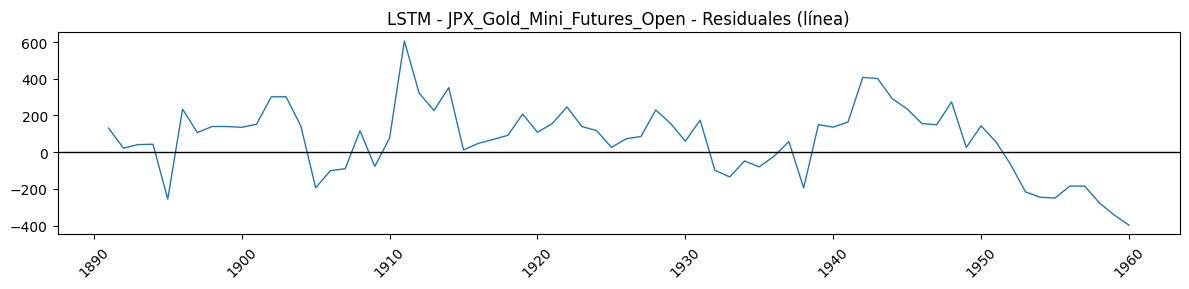

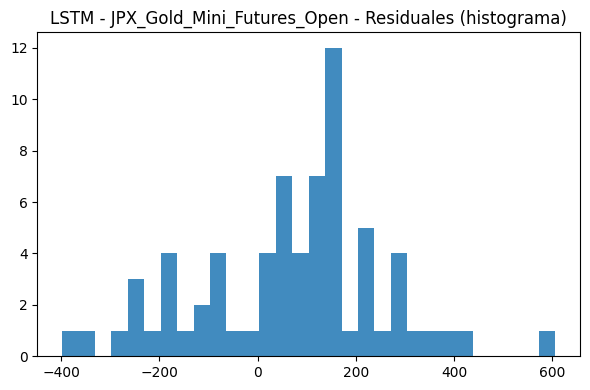

In [ ]:

import torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    torch.set_float32_matmul_precision("medium")
except Exception:
    pass
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

def make_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        pin_memory=torch.cuda.is_available(), num_workers=2,
        persistent_workers=torch.cuda.is_available()
    )

LSTM_HIDDEN   = 256
LSTM_LAYERS   = 2
LSTM_DROP     = 0.1
LSTM_EPOCHS   = 120
LSTM_BS       = 64
LSTM_LR       = 1e-3
LSTM_PATIENCE = 30
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)
        self.out_act = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        yhat = self.fc(last)
        return self.out_act(yhat)

scaler_amp = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
criterion  = nn.MSELoss()

def train_eval_lstm_amp(model, Xtr, ytr, Xte):
    train_loader = make_loader(Xtr, ytr, batch_size=LSTM_BS, shuffle=True)
    model = model.to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=LSTM_LR)

    best = float("inf"); wait = 0; best_state = None
    loss_hist = []

    for ep in range(1, LSTM_EPOCHS + 1):
        model.train(); run = 0.0
        for xb_cpu, yb_cpu in train_loader:
            xb = xb_cpu.to(DEVICE, non_blocking=True)
            yb = yb_cpu.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                pred = model(xb)
                loss = criterion(pred, yb)
            scaler_amp.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(opt)
            scaler_amp.update()
            run = run + loss.item() * xb.size(0)
        tr_mse = run / len(train_loader.dataset)
        loss_hist.append(tr_mse)

        if tr_mse < best - 1e-6:
            best = tr_mse; wait = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait = wait + 1

        if ep == 1 or ep % 5 == 0 or ep == LSTM_EPOCHS:
            print(f"Época {ep:03d}/{LSTM_EPOCHS} - Train MSE: {tr_mse:.6f} (best {best:.6f})")
        if wait >= LSTM_PATIENCE:
            print(f"Early stopping en época {ep}."); break

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    model.eval()
    preds = []
    step = 1024
    with torch.no_grad():
        for i in range(0, Xte.shape[0], step):
            xb = torch.tensor(Xte[i:i+step], dtype=torch.float32).to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                yb = model(xb)
            preds.append(yb.detach().cpu().numpy())
    yhat_scaled = np.vstack(preds)
    return yhat_scaled, loss_hist

print("\n=== LSTM (PyTorch) ===")
lstm_results = []

for tcol in ALL_TARGETS:
    print(f"\n--- LSTM para: {tcol} ---")
    y_scaler = MinMaxScaler()
    y_tr = y_scaler.fit_transform(train_df[[tcol]].values)
    y_te = y_scaler.transform(test_df[[tcol]].values)

    Xtr, ytr = make_sequences(X_train_all, y_tr, LOOKBACK)
    Xte, yte = make_sequences(X_test_all,  y_te, LOOKBACK)

    model = LSTMRegressor(input_size=Xtr.shape[-1],
                          hidden_size=LSTM_HIDDEN,
                          num_layers=LSTM_LAYERS,
                          dropout=LSTM_DROP)
    yhat_scaled, loss_hist = train_eval_lstm_amp(model, Xtr, ytr, Xte)

    yhat_inv = y_scaler.inverse_transform(yhat_scaled)
    yte_inv  = y_scaler.inverse_transform(yte)

    mae  = mean_absolute_error(yte_inv, yhat_inv)
    mse  = mean_squared_error(yte_inv, yhat_inv)
    rmse = np.sqrt(mse)
    print(f"[{tcol}] MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")
    lstm_results.append(("LSTM", tcol, float(mae), float(mse), float(rmse)))

    plot_loss_curve(loss_hist, f"LSTM - Pérdida (Train MSE) - {tcol}")
    y_true_1d = yte_inv.ravel()
    y_pred_1d = yhat_inv.ravel()
    plot_series(test_dates, y_true_1d, y_pred_1d, f"LSTM - Real vs Predicho - {tcol}")
    plot_scatter(y_true_1d, y_pred_1d, f"LSTM - Scatter - {tcol}")
    plot_residuals(test_dates, (y_pred_1d - y_true_1d), f"LSTM - {tcol}")


In [ ]:
rows = []
if 'arima_results' in globals(): rows += arima_results
if 'lin_results'   in globals(): rows += lin_results
if 'lstm_results'  in globals(): rows += lstm_results

res_df = pd.DataFrame(rows, columns=["Model","Target","MAE","MSE","RMSE"]).sort_values(["Target","Model"])
display(res_df)
print("\nPromedios por modelo:")
display(res_df.groupby("Model")[["MAE","MSE","RMSE"]].mean().sort_values("MAE"))


,Model,Target,MAE,MSE,RMSE
7,ARIMA,JPX_Gold_Mini_Futures_Close,130.571795,67576.453175,259.954714
25,LSTM,JPX_Gold_Mini_Futures_Close,169.242859,44906.378906,211.911252
16,Linear,JPX_Gold_Mini_Futures_Close,37.783371,2652.129639,51.498831
5,ARIMA,JPX_Gold_Mini_Futures_High,113.012856,68947.819018,262.579167
23,LSTM,JPX_Gold_Mini_Futures_High,146.500046,33584.546875,183.260871
14,Linear,JPX_Gold_Mini_Futures_High,29.226618,1551.598145,39.390331
6,ARIMA,JPX_Gold_Mini_Futures_Low,125.125349,63356.789529,251.707746
24,LSTM,JPX_Gold_Mini_Futures_Low,153.371368,35959.343750,189.629491
15,Linear,JPX_Gold_Mini_Futures_Low,27.398842,1296.116943,36.001624
8,ARIMA,JPX_Gold_Mini_Futures_Open,126.454081,75190.605743,274.209055



Promedios por modelo:


,MAE,MSE,RMSE
Model,,,
Linear,33.186082,2073.723294,45.050215
ARIMA,125.034582,69083.691267,262.728537
LSTM,153.232502,36129.884549,189.745343
